# Data Cleaning and EDA
**1. Read and Understand the Raw Data**

**2. EDA on Raw Data**
- Distribution of numerical variables (histograms, boxplots).
- Categories and their frequencies.
- Correlations and relationships between features.
- Missing data patterns.
- Potential data entry errors or inconsistencies.

**3. Clean Data**
- Handle missing values (impute, fill, or drop).
- Fix datatypes (e.g., convert strings to dates or numbers).
- Remove or handle outliers.
- Standardize text fields (e.g., casing, trimming whitespace).
- Fix inconsistent categories.
- Handle duplicates.
- Normalize or scale numerical data (if needed for modeling).

**4. EDA on Cleaned Data**
- Re-run descriptive stats and plots to confirm issues are resolved.
- Verify data integrity (no missing/invalid values left, distributions make sense).
- Explore features more deeply for model-building (feature engineering ideas, correlations, etc.).


## Read and Understand the Raw Data

### Taken from Kaggle
**A) Inpatient Data**

This data provides insights about the claims filed for those patients who are admitted in the hospitals. It also provides additional details like their admission and discharge dates and admit d diagnosis code.

**B) Outpatient Data**

This data provides details about the claims filed for those patients who visit hospitals and not admitted in it.

**C) Beneficiary Details Data**

This data contains beneficiary KYC details like health conditions,regioregion they belong to etc.

In [10]:
import pandas as pd
from pathlib import Path

# 1) File paths
DATA_DIR = Path("data")
p_train      = DATA_DIR / "Train-1542865627584.csv"
p_benef      = DATA_DIR / "Train_Beneficiarydata-1542865627584.csv"
p_inpatient  = DATA_DIR / "Train_Inpatientdata-1542865627584.csv"
p_outpatient = DATA_DIR / "Train_Outpatientdata-1542865627584.csv"

# 2) Helper: peek at columns & auto-detect likely date columns
def detect_date_cols(path, sample_rows=1000):
    sample = pd.read_csv(path, nrows=sample_rows, low_memory=False)
    # Heuristic: any column name that looks like a date
    candidates = [c for c in sample.columns if any(s in c.lower() for s in ["date", "dt", "dob", "dod"])]
    return sorted(set(candidates))

# (Optional) See which columns will be parsed as dates
date_cols = {
    "train":      detect_date_cols(p_train),
    "benef":      detect_date_cols(p_benef),
    "inpatient":  detect_date_cols(p_inpatient),
    "outpatient": detect_date_cols(p_outpatient),
}
print("Guessed date columns:", date_cols)

# 3) Read with good defaults
# - low_memory=False => better type inference
# - dtype_backend="pyarrow" (if pandas >= 2.0) => memory efficient + nullable dtypes
common_read_kwargs = dict(
    low_memory=False,
)
try:
    # If your pandas supports it, this helps memory use and null handling
    common_read_kwargs["dtype_backend"] = "pyarrow"
except TypeError:
    pass  # older pandas, ignore

date_parser = lambda x: pd.to_datetime(x, format="%Y-%m-%d", errors="coerce")

df_train = pd.read_csv(p_train,      parse_dates=date_cols["train"],      date_format=date_parser, **common_read_kwargs)
df_bene  = pd.read_csv(p_benef,      parse_dates=date_cols["benef"],      date_format=date_parser, **common_read_kwargs)
df_inp   = pd.read_csv(p_inpatient,  parse_dates=date_cols["inpatient"],  date_format=date_parser, **common_read_kwargs)
df_out   = pd.read_csv(p_outpatient, parse_dates=date_cols["outpatient"], date_format=date_parser, **common_read_kwargs)

# 4) Quick sanity checks / previews
for name, df in [("train", df_train), ("benef", df_bene), ("inpatient", df_inp), ("outpatient", df_out)]:
    print(f"\n== {name.upper()} ==")
    print("shape:", df.shape)
    print(df.head(3))
    print(df.dtypes.head(10))  # first 10 dtypes to keep output short



Guessed date columns: {'train': [], 'benef': ['DOB', 'DOD'], 'inpatient': ['AdmissionDt', 'ClaimEndDt', 'ClaimStartDt', 'DischargeDt'], 'outpatient': ['ClaimEndDt', 'ClaimStartDt']}

== TRAIN ==
shape: (5410, 2)
   Provider PotentialFraud
0  PRV51001             No
1  PRV51003            Yes
2  PRV51004             No
Provider          string[pyarrow]
PotentialFraud    string[pyarrow]
dtype: object

== BENEF ==
shape: (138556, 25)
      BeneID         DOB   DOD  Gender  Race RenalDiseaseIndicator  State  \
0  BENE11001  1943-01-01  <NA>       1     1                     0     39   
1  BENE11002  1936-09-01  <NA>       2     1                     0     39   
2  BENE11003  1936-08-01  <NA>       1     1                     0     52   

   County  NoOfMonths_PartACov  NoOfMonths_PartBCov  ...  \
0     230                   12                   12  ...   
1     280                   12                   12  ...   
2     590                   12                   12  ...   

   ChronicCond_

### From visual observation, there are:
- A single shared key across all three = `BeneID`
- Inpatient and outpatient both also have ClaimID, Provider, and many matching claim fields

Structure:
- Keep 2 curated tables: `beneficiaries.parquet` and `claims.parquet`
- Concatenate inpatient and outpatient row-wise into a single `claims` table 


Joining:
- Join on `BeneID` at feature-building time to avoid duplication/leakage


## EDA on Raw Data

In [15]:

import os, json
import numpy as np
import matplotlib.pyplot as plt
from pandas.api.types import is_object_dtype
from pandas import CategoricalDtype

EDA_CFG = {
    "out_dir": "eda_report",
    "sample_rows": 10000,            # None to use all rows
    "max_numeric_hist": 10,          # per dataset
    "max_categorical_bar": 10,       # per dataset
    "top_k_categories": 15,          # bars per categorical col
    "figsize": (8, 5),
    "bene_key": "BeneID",
    "claim_key": "ClaimID",
}

from pathlib import Path
def _ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)

def _downsample(df: pd.DataFrame, n: int | None) -> pd.DataFrame:
    if n is None or len(df) <= n:
        return df
    return df.sample(n, random_state=42)


DATE_FORMATS = [
    "%Y-%m-%d",      # 2011-12-31
    "%m/%d/%Y",      # 12/31/2011
    "%d/%m/%Y",      # 31/12/2011
    "%Y%m%d",        # 20111231
    "%d-%b-%Y",      # 31-Dec-2011
]

def _parse_dates_series(s: pd.Series) -> pd.Series:
    # Try vectorized parses with common formats first (fast, no warnings)
    for fmt in DATE_FORMATS:
        parsed = pd.to_datetime(s, format=fmt, errors="coerce")
        # If a meaningful fraction parsed, accept this format
        if parsed.notna().mean() >= 0.7:  # tweak threshold as you like
            return parsed
    # Fallback to general parser (quiet)
    return pd.to_datetime(s, errors="coerce")

def _reparse_dates(df: pd.DataFrame, date_cols: list[str]):
    for c in date_cols:
        if c in df.columns:
            df[c] = _parse_dates_series(df[c])

def _numeric_cols(df: pd.DataFrame) -> list[str]:
    return [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

def _categorical_cols(df: pd.DataFrame, max_unique=100) -> list[str]:
    cols = []
    for c in df.columns:
        dt = df[c].dtype
        if is_object_dtype(dt) or isinstance(dt, CategoricalDtype):
            # skip obvious IDs / high-card columns
            nunq = df[c].nunique(dropna=True)
            if nunq <= max_unique and not any(t in c.upper() for t in ["ID","UUID","KEY"]):
                cols.append(c)
    return cols


def _basic_overview(df: pd.DataFrame, name: str) -> dict:
    return {"dataset": name, "rows": len(df), "cols": df.shape[1],
            "sample_cols": ", ".join(df.columns[:8]) + ("..." if df.shape[1] > 8 else "")}

def _schema_table(df: pd.DataFrame, name: str) -> pd.DataFrame:
    rows = []
    for c in df.columns:
        rows.append({"dataset": name, "column": c, "dtype_inferred": str(df[c].dtype),
                     "non_null": int(df[c].notna().sum()), "nulls": int(df[c].isna().sum()),
                     "null_rate": float(df[c].isna().mean())})
    return pd.DataFrame(rows)

def _key_checks(df: pd.DataFrame, name: str, bene_key: str, claim_key: str) -> list[dict]:
    res = []
    for key_col in [bene_key, claim_key]:
        if key_col in df.columns:
            res.append({"dataset": name, "key": key_col, "present": True,
                        "null_count": int(df[key_col].isna().sum()),
                        "duplicate_count": int(df.duplicated(subset=[key_col]).sum())})
        else:
            res.append({"dataset": name, "key": key_col, "present": False,
                        "null_count": None, "duplicate_count": None})
    return res

def _numeric_stats(df: pd.DataFrame, name: str) -> pd.DataFrame:
    cols = _numeric_cols(df)
    rows = []
    for c in cols:
        s = df[c].dropna()
        if s.empty: continue
        rows.append({"dataset": name, "column": c, "count": int(s.size),
                     "mean": float(s.mean()), "std": float(s.std(ddof=0)),
                     "min": float(s.min()), "p50": float(s.quantile(0.5)),
                     "p95": float(s.quantile(0.95)), "max": float(s.max())})
    return pd.DataFrame(rows)

def _categorical_stats(df: pd.DataFrame, name: str, top_k=15) -> pd.DataFrame:
    cols = _categorical_cols(df)
    rows = []
    for c in cols:
        vc = df[c].astype("string").value_counts(dropna=True).head(top_k)
        for val, cnt in vc.items():
            rows.append({"dataset": name, "column": c, "value": str(val), "count": int(cnt)})
    return pd.DataFrame(rows)

def _plot_numerics(df: pd.DataFrame, name: str, outdir: Path, limit: int, figsize=(8,5)):
    for c in _numeric_cols(df)[:limit]:
        try:
            plt.figure(figsize=figsize)
            df[c].dropna().hist(bins=50)
            plt.title(f"{name} | {c} (hist)")
            plt.xlabel(c); plt.ylabel("count")
            plt.tight_layout()
            plt.savefig(outdir / f"{name}__NUM__{c}.png", dpi=120)
            plt.close()
        except Exception:
            plt.close()

def _plot_categoricals(df: pd.DataFrame, name: str, outdir: Path, limit: int, topk: int, figsize=(8,5)):
    for c in _categorical_cols(df)[:limit]:
        try:
            vc = df[c].astype("string").value_counts(dropna=True).head(topk)
            plt.figure(figsize=figsize)
            vc[::-1].plot(kind="barh")
            plt.title(f"{name} | {c} (top {topk})")
            plt.xlabel("count"); plt.ylabel(c)
            plt.tight_layout()
            plt.savefig(outdir / f"{name}__CAT__{c}.png", dpi=120)
            plt.close()
        except Exception:
            plt.close()

def _column_intersections(*dfs_with_names):
    sets = [(name, set(df.columns)) for name, df in dfs_with_names]
    pairs = {}
    for i in range(len(sets)):
        for j in range(i+1, len(sets)):
            a, ac = sets[i]; b, bc = sets[j]
            pairs[f"{a} ∩ {b}"] = sorted(list(ac & bc))
    return pairs

def _linkage_coverage(left_df: pd.DataFrame, right_df: pd.DataFrame, key: str) -> dict:
    if key not in left_df.columns or key not in right_df.columns:
        return {"left_rows": len(left_df), "right_rows": len(right_df),
                "key_in_left": key in left_df.columns, "key_in_right": key in right_df.columns,
                "coverage_rate": float("nan")}
    left_ids = set(left_df[key].dropna().astype(str).unique())
    right_ids = right_df[key].dropna().astype(str)
    rate = right_ids.isin(left_ids).mean() if len(right_ids) else float("nan")
    return {"left_rows": len(left_df), "right_rows": len(right_df), "coverage_rate": float(rate)}


In [16]:

# ----------------------
# 4) Run EDA
# ----------------------
out = Path(EDA_CFG["out_dir"]); plots = out / "plots"
out.mkdir(parents=True, exist_ok=True); plots.mkdir(parents=True, exist_ok=True)

# (Re)parse dates safely (based on guessed columns earlier)
def _reparse_block(df, cols): 
    for c in cols: 
        if c in df.columns: 
            df[c] = pd.to_datetime(df[c], errors="coerce")

_reparse_block(df_train, date_cols.get("train", []))
_reparse_block(df_bene,  date_cols.get("benef", []))
_reparse_block(df_inp,   date_cols.get("inpatient", []))
_reparse_block(df_out,   date_cols.get("outpatient", []))

# Overview & schema/nulls
overview = [
    _basic_overview(df_train, "Train"),
    _basic_overview(df_bene,  "Beneficiary"),
    _basic_overview(df_inp,   "Inpatient"),
    _basic_overview(df_out,   "Outpatient"),
]
pd.DataFrame(overview).to_csv(out / "summary_overview.csv", index=False)

schema = pd.concat([
    _schema_table(df_train, "Train"),
    _schema_table(df_bene,  "Beneficiary"),
    _schema_table(df_inp,   "Inpatient"),
    _schema_table(df_out,   "Outpatient"),
], ignore_index=True)
schema.to_csv(out / "schema_summary.csv", index=False)
schema[["dataset","column","null_rate"]].to_csv(out / "null_rates.csv", index=False)

# Key checks
key_rows = []
for (name, df) in [("Train", df_train), ("Beneficiary", df_bene), ("Inpatient", df_inp), ("Outpatient", df_out)]:
    key_rows += _key_checks(df, name, EDA_CFG["bene_key"], EDA_CFG["claim_key"])
pd.DataFrame(key_rows).to_csv(out / "key_checks.csv", index=False)

# Light stats (sampled)
def _ds(x): 
    return _downsample(x, EDA_CFG["sample_rows"])

ds_train, ds_bene, ds_inp, ds_out = map(_ds, [df_train, df_bene, df_inp, df_out])

num_stats = pd.concat([
    _numeric_stats(ds_train, "Train"),
    _numeric_stats(ds_bene,  "Beneficiary"),
    _numeric_stats(ds_inp,   "Inpatient"),
    _numeric_stats(ds_out,   "Outpatient"),
], ignore_index=True)
num_stats.to_csv(out / "top_numeric_stats.csv", index=False)

cat_stats = pd.concat([
    _categorical_stats(ds_train, "Train", top_k=EDA_CFG["top_k_categories"]),
    _categorical_stats(ds_bene,  "Beneficiary", top_k=EDA_CFG["top_k_categories"]),
    _categorical_stats(ds_inp,   "Inpatient", top_k=EDA_CFG["top_k_categories"]),
    _categorical_stats(ds_out,   "Outpatient", top_k=EDA_CFG["top_k_categories"]),
], ignore_index=True)
cat_stats.to_csv(out / "top_categorical_stats.csv", index=False)

# Plots
_plot_numerics(ds_train, "Train", plots, EDA_CFG["max_numeric_hist"], EDA_CFG["figsize"])
_plot_numerics(ds_bene,  "Beneficiary", plots, EDA_CFG["max_numeric_hist"], EDA_CFG["figsize"])
_plot_numerics(ds_inp,   "Inpatient", plots, EDA_CFG["max_numeric_hist"], EDA_CFG["figsize"])
_plot_numerics(ds_out,   "Outpatient", plots, EDA_CFG["max_numeric_hist"], EDA_CFG["figsize"])

_plot_categoricals(ds_train, "Train", plots, EDA_CFG["max_categorical_bar"], EDA_CFG["top_k_categories"], EDA_CFG["figsize"])
_plot_categoricals(ds_bene,  "Beneficiary", plots, EDA_CFG["max_categorical_bar"], EDA_CFG["top_k_categories"], EDA_CFG["figsize"])
_plot_categoricals(ds_inp,   "Inpatient", plots, EDA_CFG["max_categorical_bar"], EDA_CFG["top_k_categories"], EDA_CFG["figsize"])
_plot_categoricals(ds_out,   "Outpatient", plots, EDA_CFG["max_categorical_bar"], EDA_CFG["top_k_categories"], EDA_CFG["figsize"])

# Column intersections
inter = _column_intersections(
    ("Train", df_train),
    ("Beneficiary", df_bene),
    ("Inpatient", df_inp),
    ("Outpatient", df_out),
)
with open(out / "column_intersections.json", "w") as f:
    json.dump(inter, f, indent=2)

# Linkage coverage: beneficiaries ↔ claims (inpatient ∪ outpatient)
claims_union = pd.concat([df_inp.assign(claim_setting="inpatient"),
                          df_out.assign(claim_setting="outpatient")],
                         ignore_index=True, sort=False)

coverage = _linkage_coverage(df_bene, claims_union, EDA_CFG["bene_key"])
pd.DataFrame([coverage]).to_csv(out / "linkage_coverage.csv", index=False)

print("EDA complete. Artifacts written to:", out.resolve())


EDA complete. Artifacts written to: /Users/Clare/Desktop/y3s1/insurance-fraud-machine-learning-model/eda_report


eda_report/column_intersections.json
eda_report/key_checks.csv
eda_report/linkage_coverage.csv
eda_report/null_rates.csv
eda_report/plots
eda_report/plots/Beneficiary__NUM__ChronicCond_Alzheimer.png
eda_report/plots/Beneficiary__NUM__ChronicCond_Cancer.png
eda_report/plots/Beneficiary__NUM__ChronicCond_Heartfailure.png
eda_report/plots/Beneficiary__NUM__ChronicCond_KidneyDisease.png
eda_report/plots/Beneficiary__NUM__County.png
eda_report/plots/Beneficiary__NUM__Gender.png
eda_report/plots/Beneficiary__NUM__NoOfMonths_PartACov.png
eda_report/plots/Beneficiary__NUM__NoOfMonths_PartBCov.png
eda_report/plots/Beneficiary__NUM__Race.png
eda_report/plots/Beneficiary__NUM__State.png
eda_report/plots/Inpatient__NUM__ClmProcedureCode_1.png
eda_report/plots/Inpatient__NUM__ClmProcedureCode_2.png
eda_report/plots/Inpatient__NUM__ClmProcedureCode_3.png
eda_report/plots/Inpatient__NUM__ClmProcedureCode_4.png
eda_report/plots/Inpatient__NUM__ClmProcedureCode_5.png
eda_report/plots/Inpatient__NUM__De

,dataset,key,present,null_count,duplicate_count
0,Train,BeneID,False,NaN,NaN
1,Train,ClaimID,False,NaN,NaN
2,Beneficiary,BeneID,True,0.0,0.0
3,Beneficiary,ClaimID,False,NaN,NaN
4,Inpatient,BeneID,True,0.0,9185.0



=== linkage_coverage.csv ===


,left_rows,right_rows,coverage_rate
0,138556,558211,1.0



=== null_rates.csv ===


...


=== summary_overview.csv ===


,dataset,rows,cols,sample_cols
0,Train,5410,2,"Provider, PotentialFraud"
1,Beneficiary,138556,25,"BeneID, DOB, DOD, Gender, Race, RenalDiseaseIn..."
2,Inpatient,40474,30,"BeneID, ClaimID, ClaimStartDt, ClaimEndDt, Pro..."
3,Outpatient,517737,27,"BeneID, ClaimID, ClaimStartDt, ClaimEndDt, Pro..."



=== top_categorical_stats.csv ===
Could not read: No columns to parse from file

=== top_numeric_stats.csv ===


,dataset,column,count,mean,std,min,p50,p95,max
0,Beneficiary,Gender,10000,1.5720,0.494789,1.0,2.0,2.00,2.0
1,Beneficiary,Race,10000,1.2554,0.725514,1.0,1.0,3.00,5.0
2,Beneficiary,State,10000,25.7273,15.259035,1.0,25.0,50.00,54.0
3,Beneficiary,County,10000,376.5997,265.718992,0.0,340.0,883.05,999.0
4,Beneficiary,NoOfMonths_PartACov,10000,11.8853,1.155657,0.0,12.0,12.00,12.0



=== column_intersections.json ===
{
  "Train \u2229 Beneficiary": [],
  "Train \u2229 Inpatient": [
    "Provider"
  ],
  "Train \u2229 Outpatient": [
    "Provider"
  ],
  "Beneficiary \u2229 Inpatient": [
    "BeneID"
  ],
  "Beneficiary \u2229 Outpatient": [
    "BeneID"
  ],
  "Inpatient \u2229 Outpatient": [
    "AttendingPhysician",
    "BeneID",
    "ClaimEndDt",
    "ClaimID",
    "ClaimStartDt",
    "ClmAdmitDiagnosisCode",
    "ClmDiagnosisCode_1",
    "ClmDiagnosisCode_10",
    "ClmDiagnosisCode_2",
    "ClmDiagnosisCode_3",
    "ClmDiagnosisCode_4",
    "ClmDiagnosisCode_5",
    "ClmDiagnosisCode_6",
    "ClmDiagnosisCode_7",
    "ClmDiagnosisCode_8",
    "ClmDiagnosisCode_9",
    "ClmProcedureCode_1",
    "ClmProcedureCode_2",
    "ClmProcedureCode_3",
    "ClmProcedureCode_4",
    "ClmProcedureCode_5",
    "ClmProcedureCode_6",
    "DeductibleAmtPaid",
    "InscClaimAmtReimbursed",
    "OperatingPhysician",
    "OtherPhysician",
    "Provider"
  ]
}

=== Generated plots 

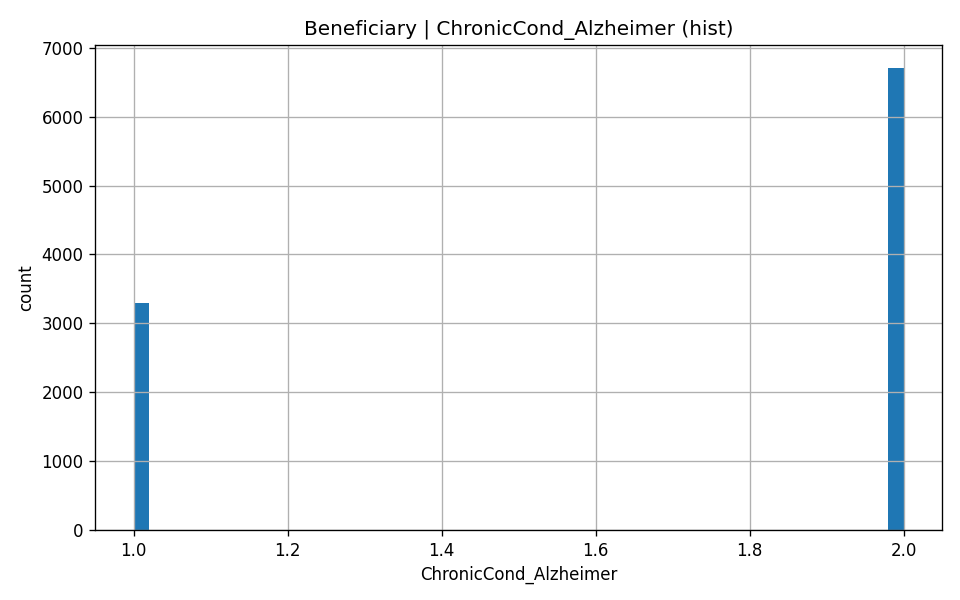


📊 Beneficiary__NUM__ChronicCond_Cancer.png


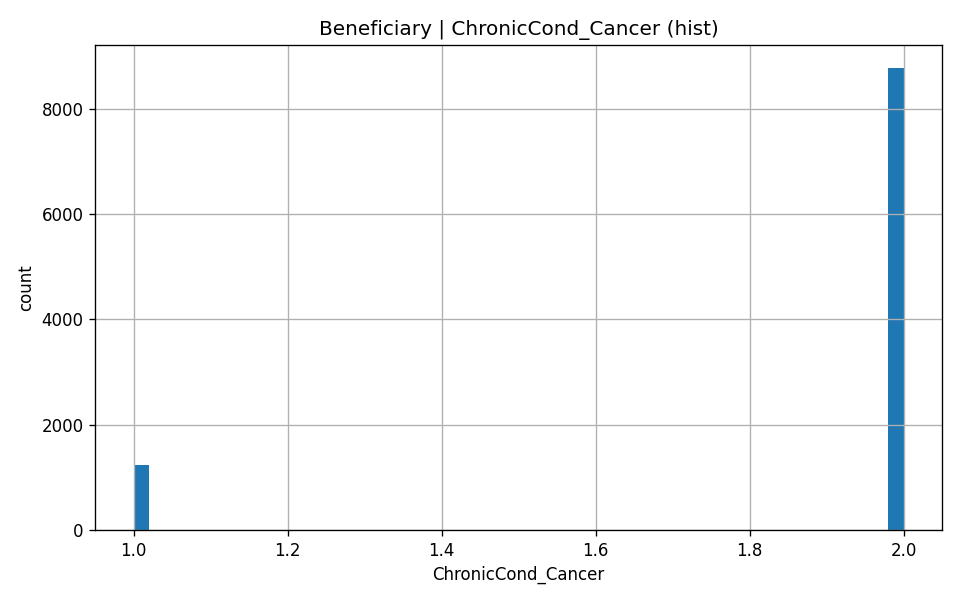


📊 Beneficiary__NUM__ChronicCond_Heartfailure.png


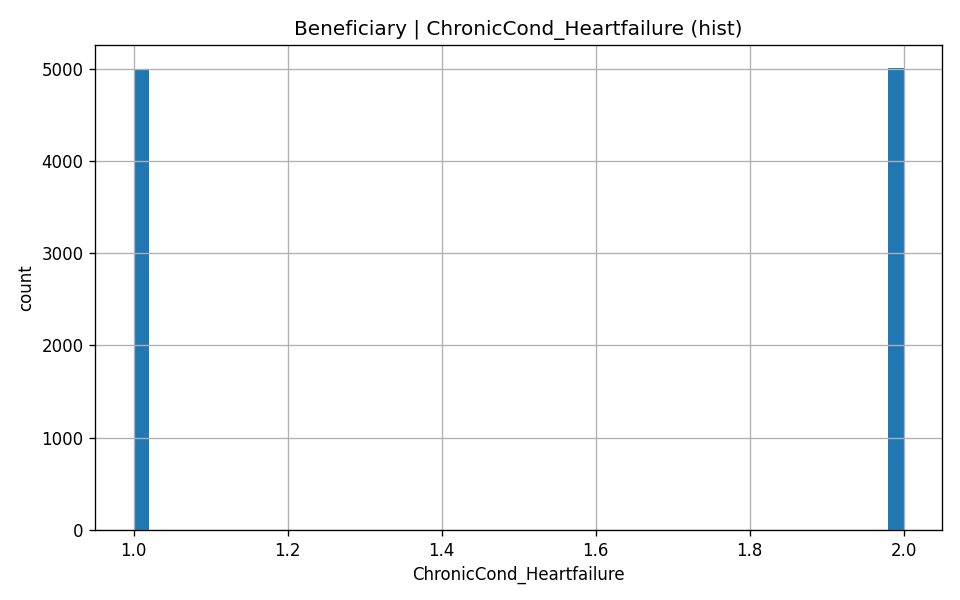


📊 Beneficiary__NUM__ChronicCond_KidneyDisease.png


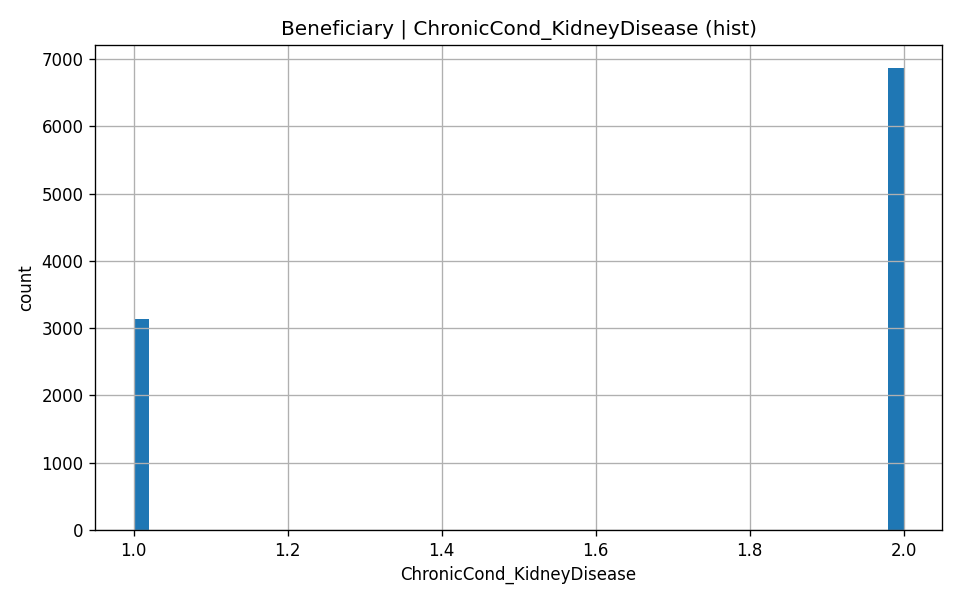


📊 Beneficiary__NUM__County.png


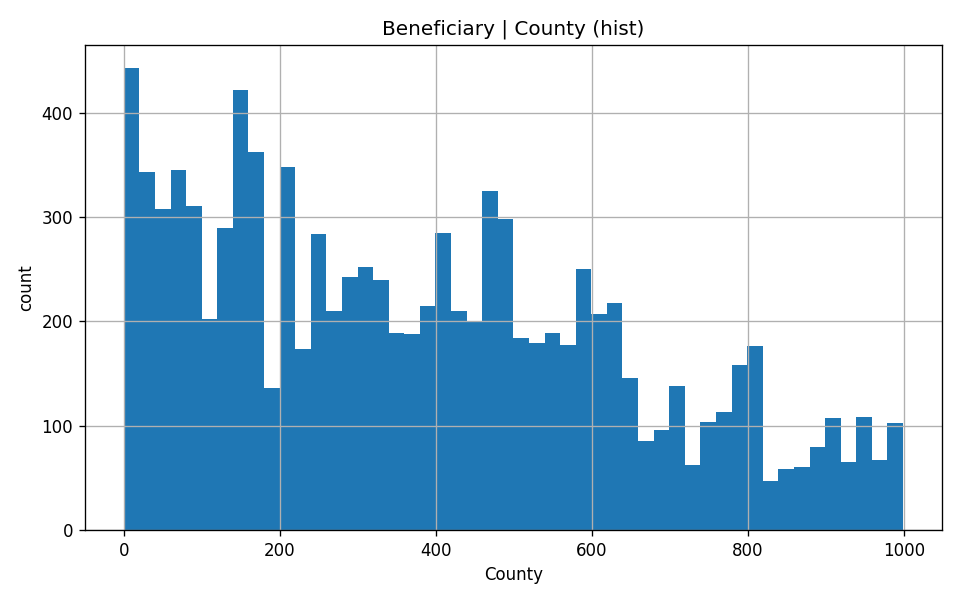


📊 Beneficiary__NUM__Gender.png


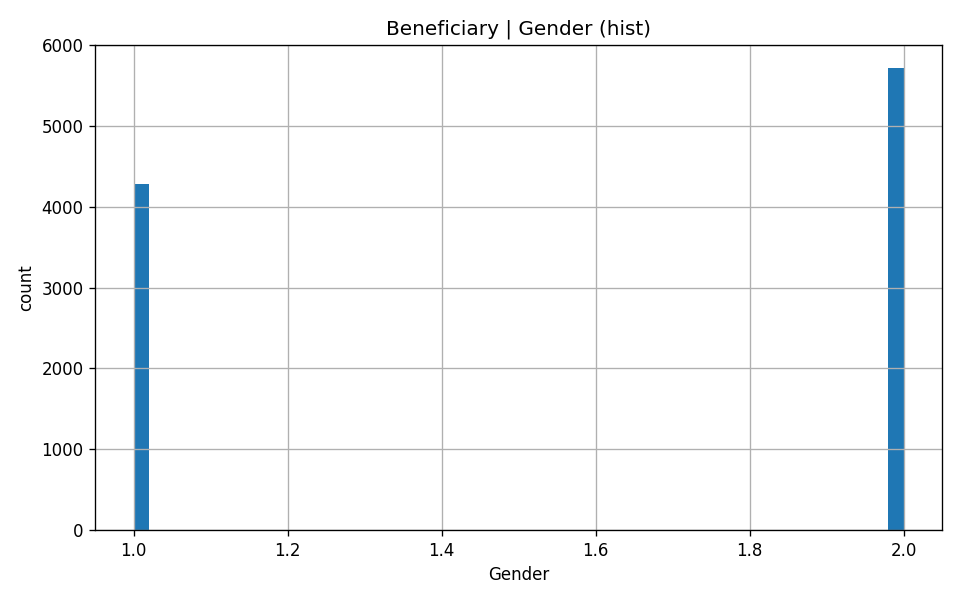


📊 Beneficiary__NUM__NoOfMonths_PartACov.png


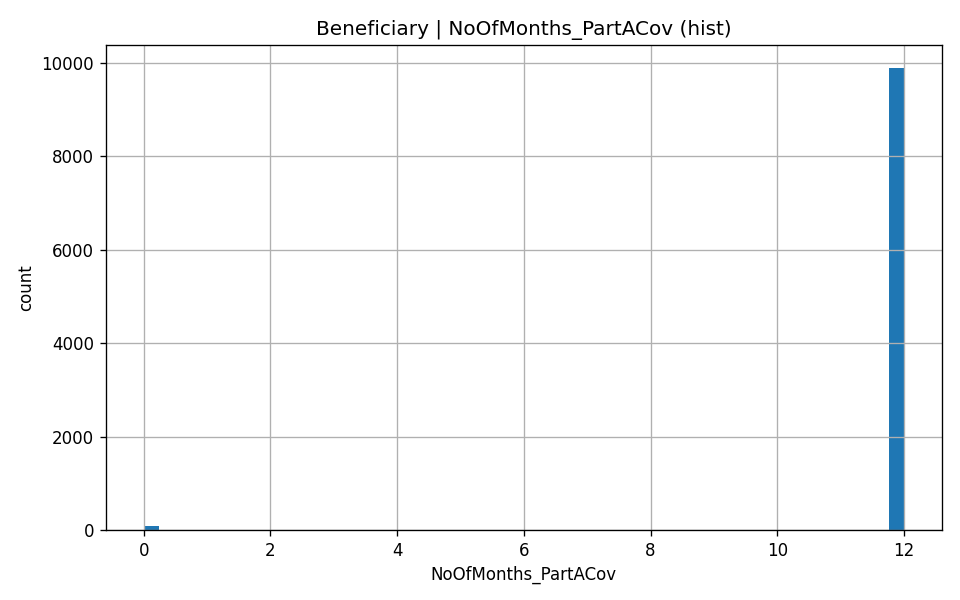


📊 Beneficiary__NUM__NoOfMonths_PartBCov.png


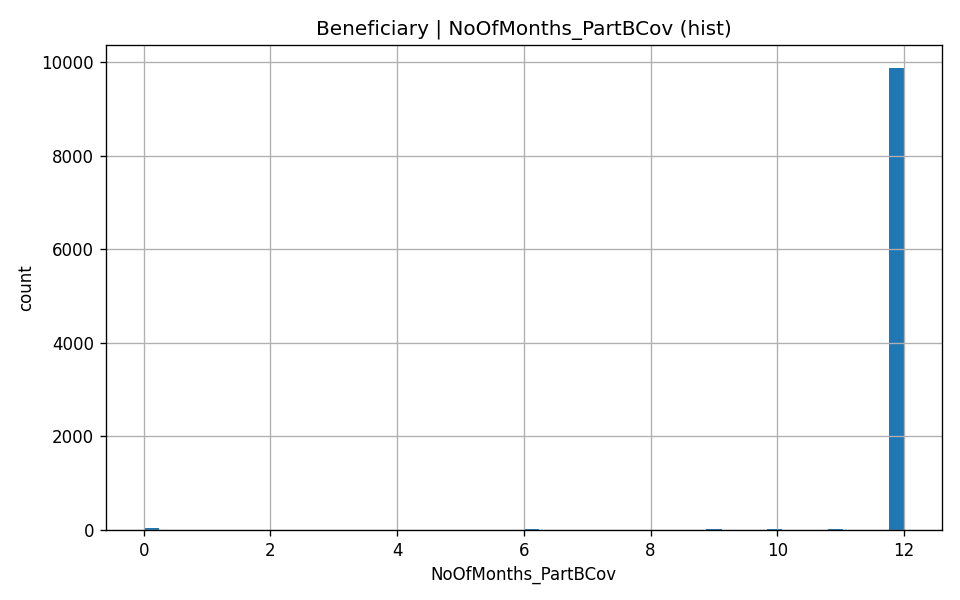


📊 Beneficiary__NUM__Race.png


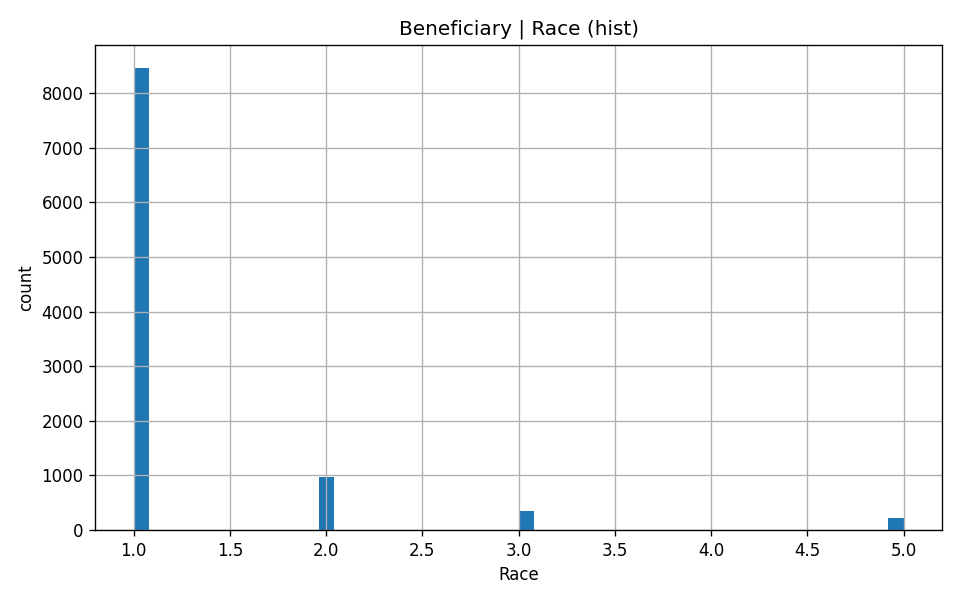


📊 Beneficiary__NUM__State.png


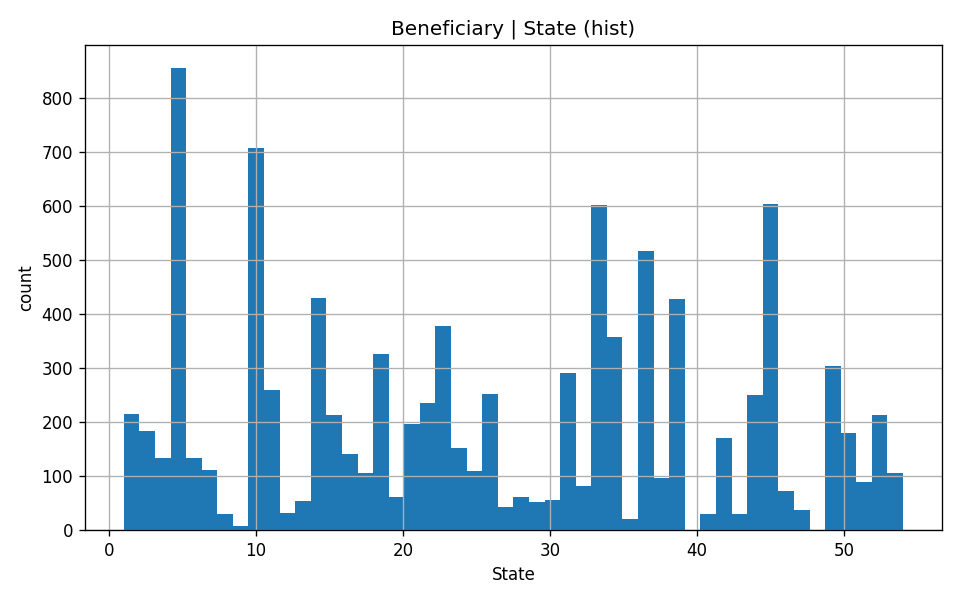


📊 Inpatient__NUM__ClmProcedureCode_1.png


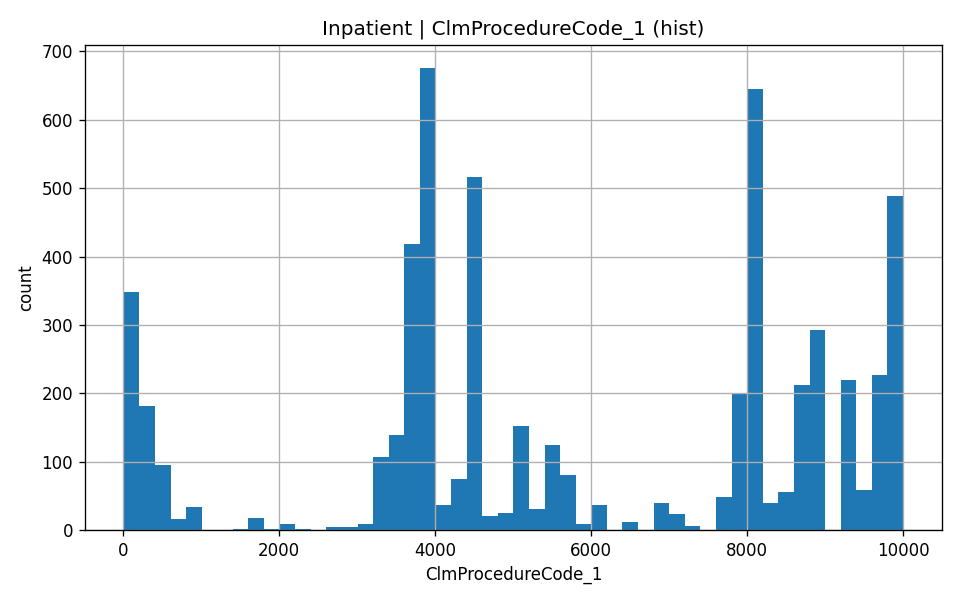


📊 Inpatient__NUM__ClmProcedureCode_2.png


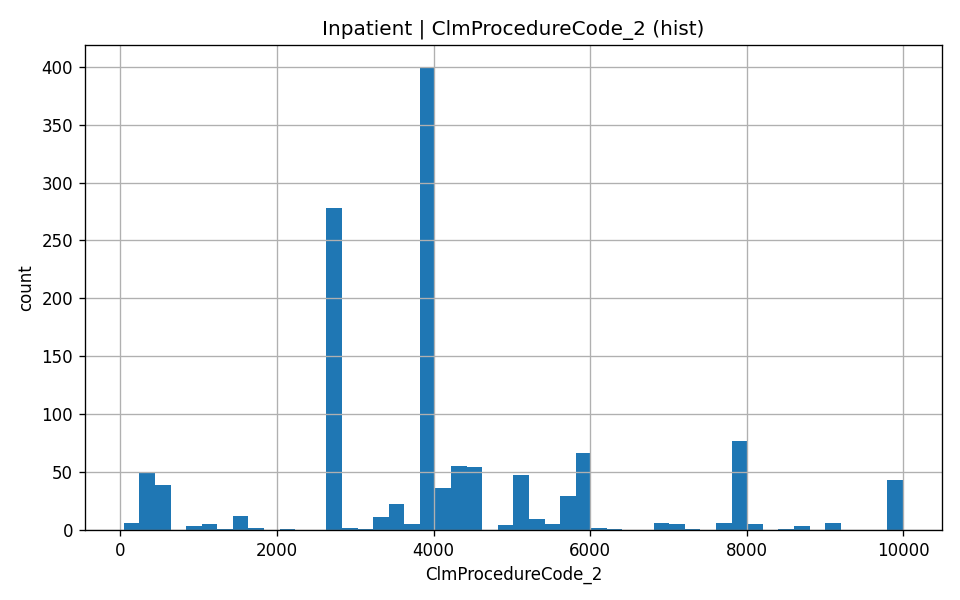


📊 Inpatient__NUM__ClmProcedureCode_3.png


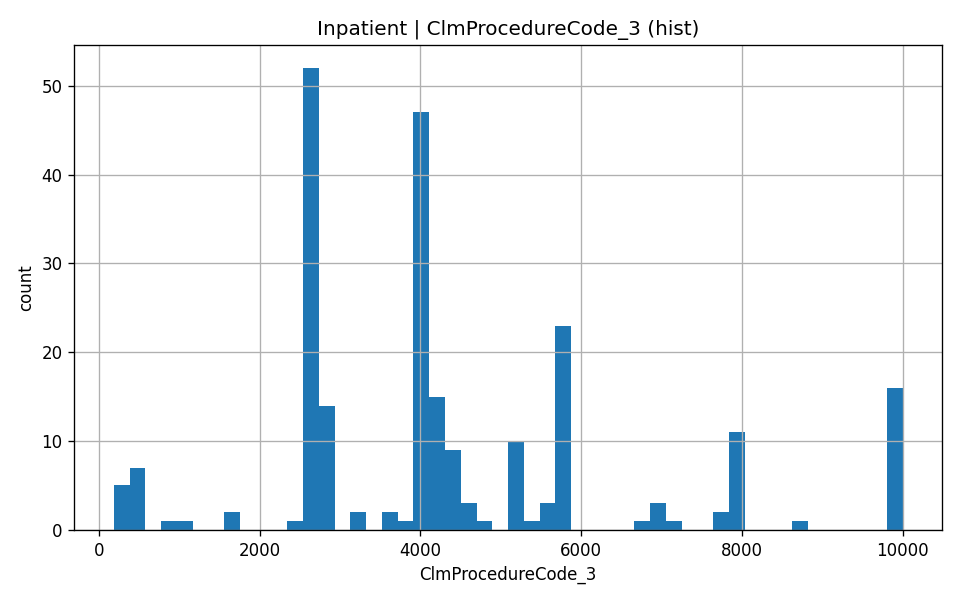


📊 Inpatient__NUM__ClmProcedureCode_4.png


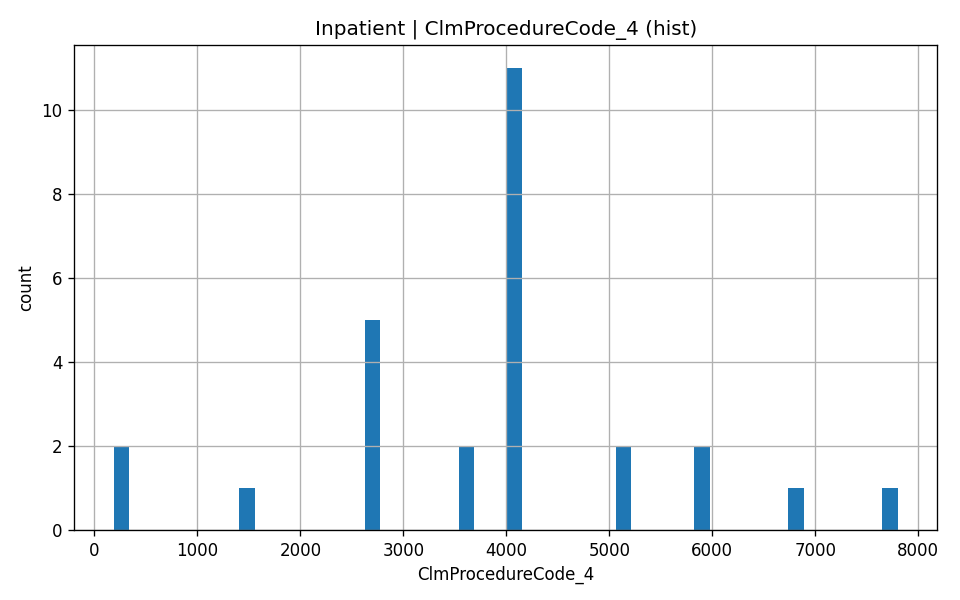


📊 Inpatient__NUM__ClmProcedureCode_5.png


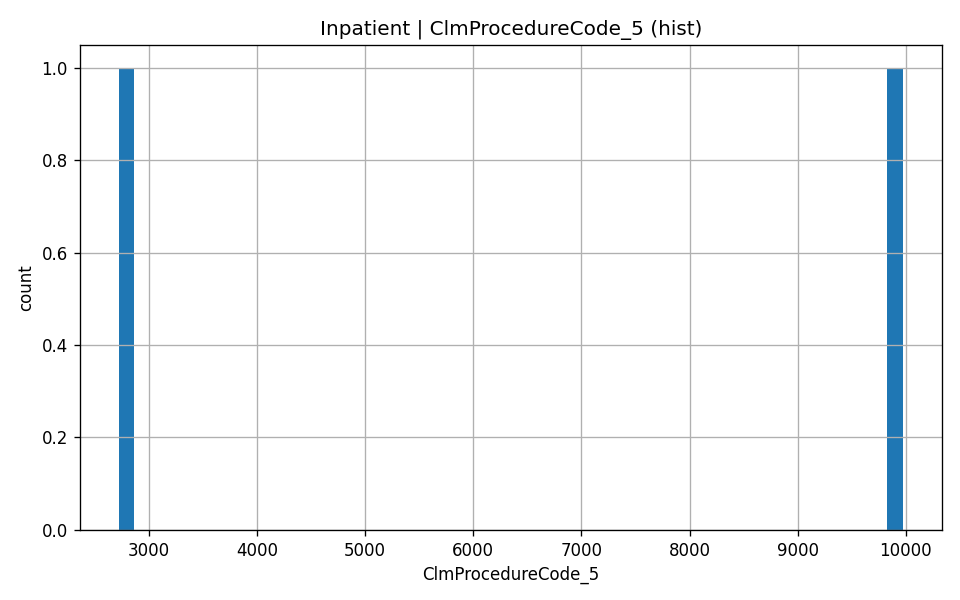


📊 Inpatient__NUM__DeductibleAmtPaid.png


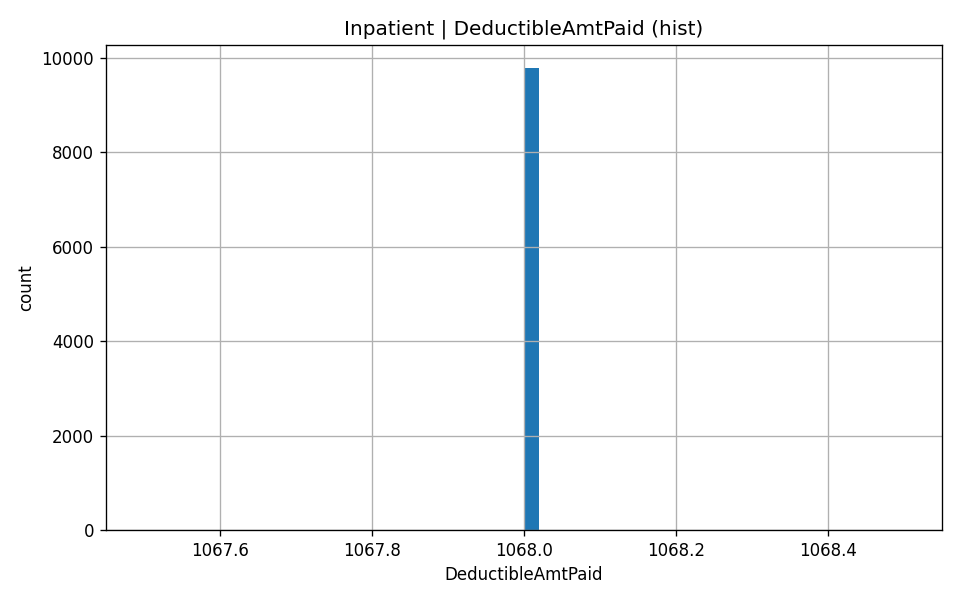


📊 Inpatient__NUM__InscClaimAmtReimbursed.png


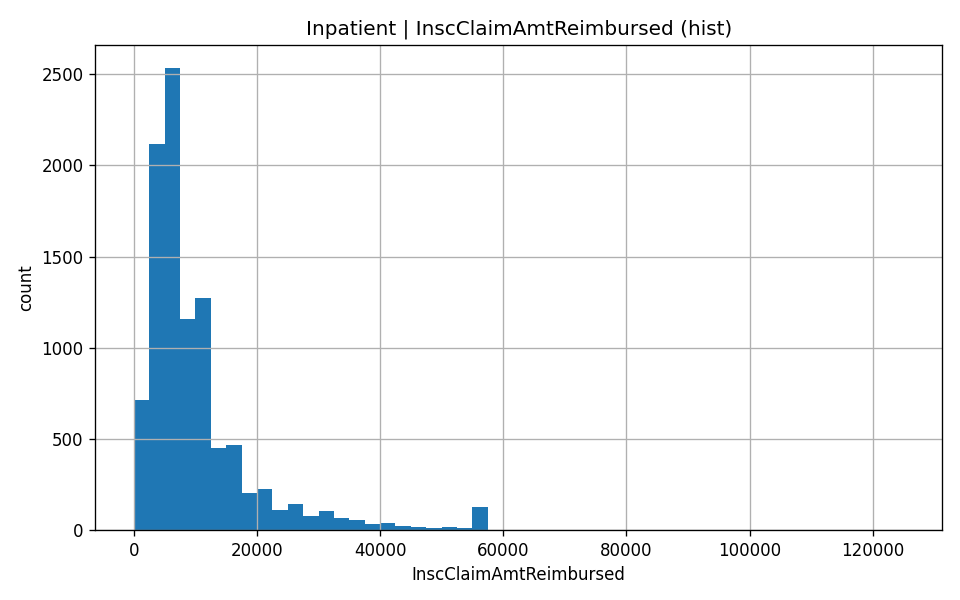


📊 Outpatient__NUM__ClmProcedureCode_1.png


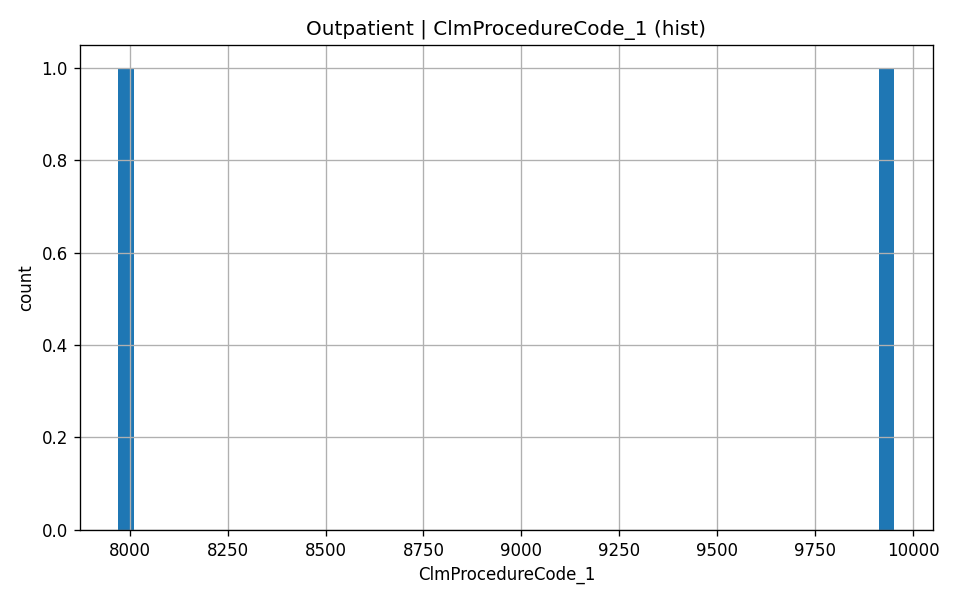


📊 Outpatient__NUM__ClmProcedureCode_2.png


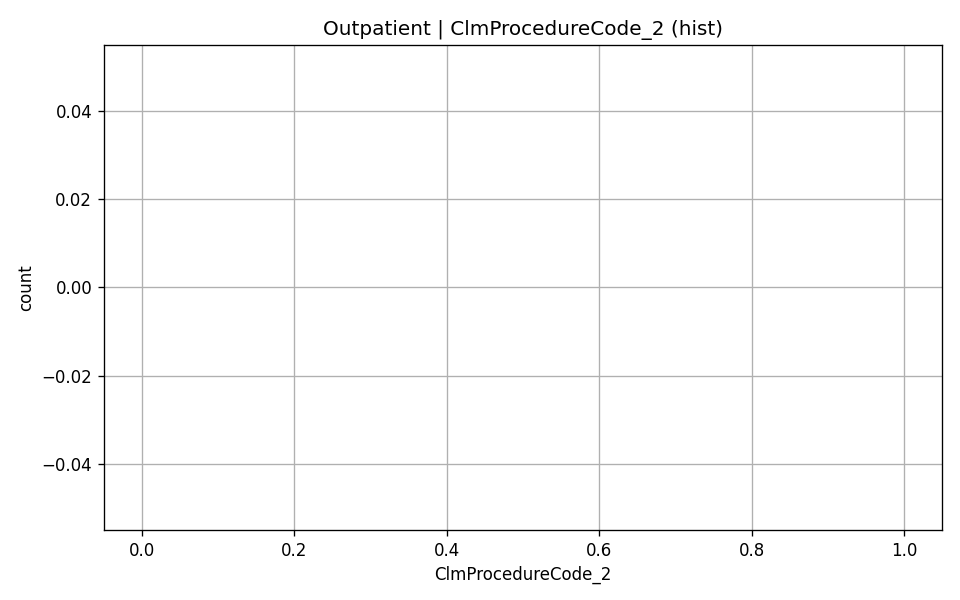


📊 Outpatient__NUM__ClmProcedureCode_3.png


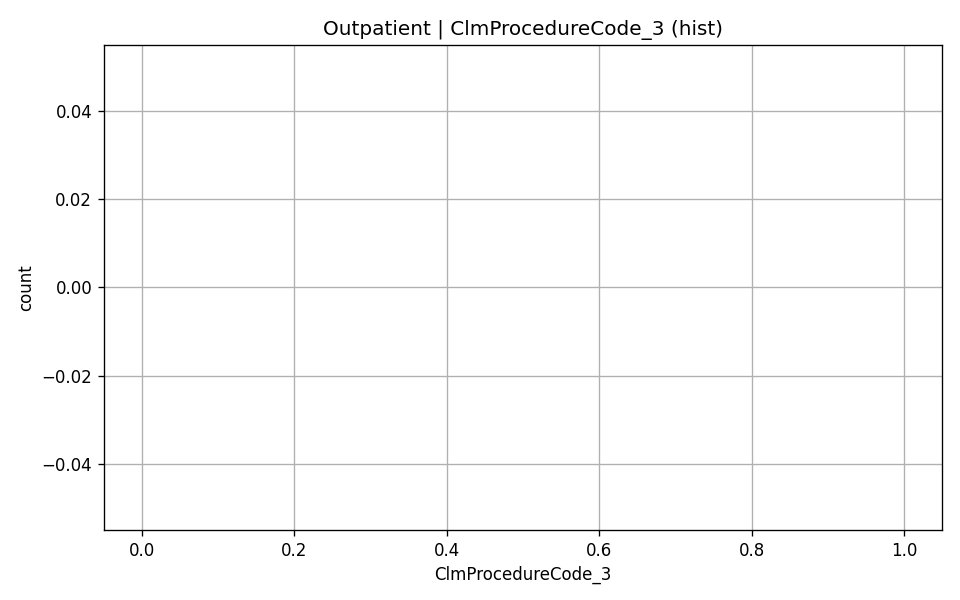


📊 Outpatient__NUM__ClmProcedureCode_4.png


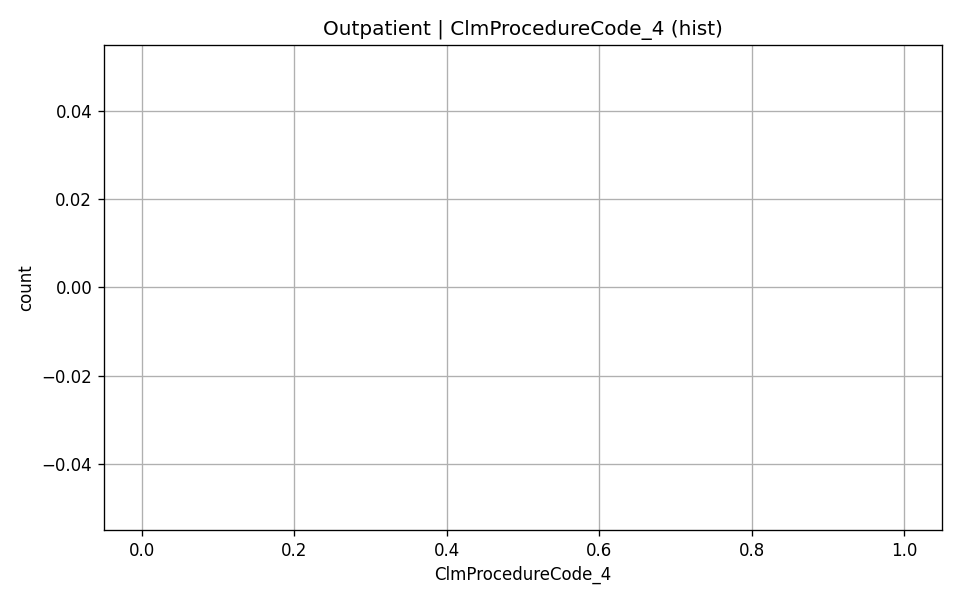


📊 Outpatient__NUM__DeductibleAmtPaid.png


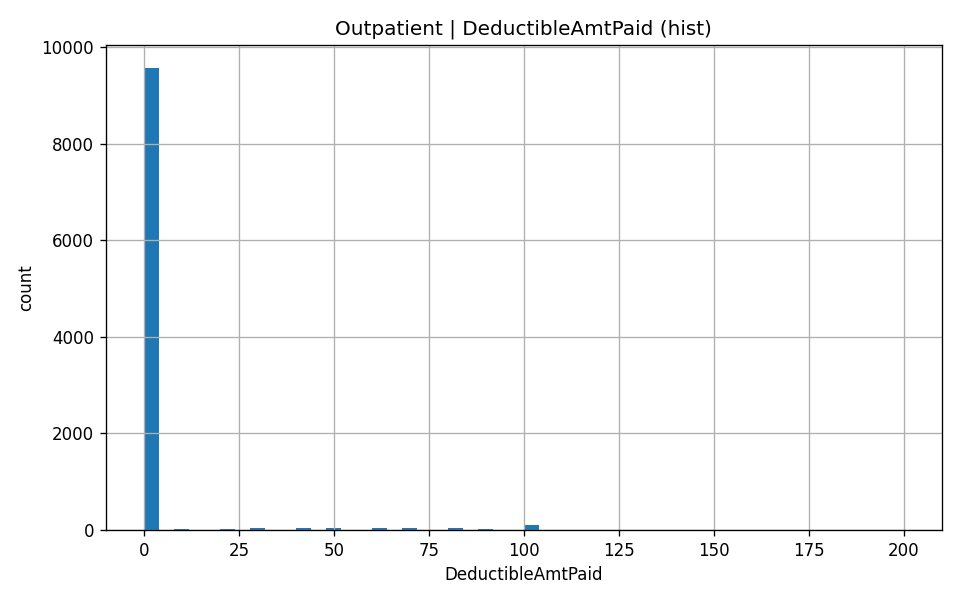


📊 Outpatient__NUM__InscClaimAmtReimbursed.png


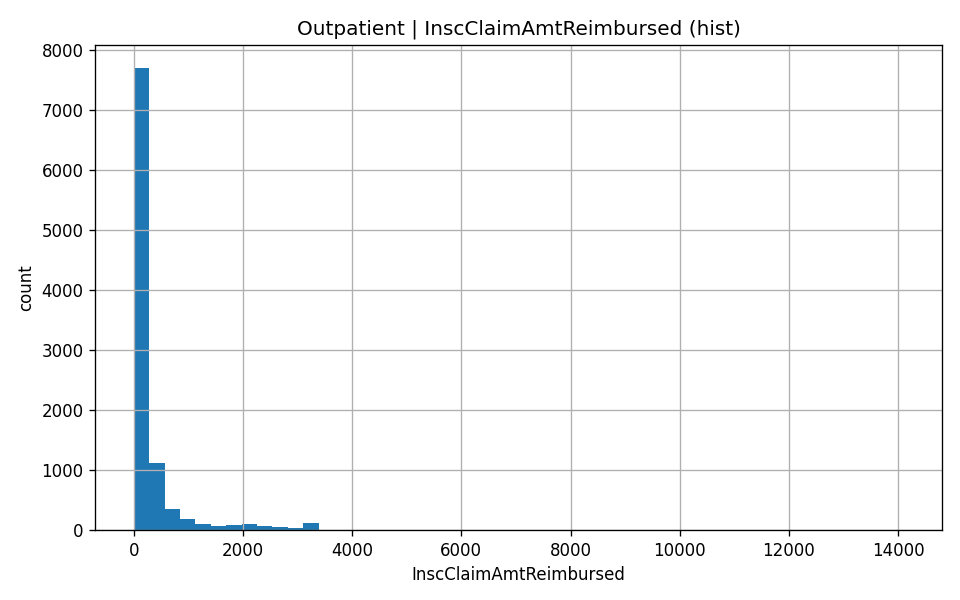

,left_rows,right_rows,coverage_rate
0,138556,558211,1.0


In [19]:
from pathlib import Path
import pandas as pd
import json
from IPython.display import Image, display

# ----------------------------
# 1) List everything in eda_report
# ----------------------------
out_dir = Path("eda_report")
for p in sorted(out_dir.rglob("*")):
    print(p)

# ----------------------------
# 2) Preview CSVs
# ----------------------------
for csv_file in sorted(out_dir.glob("*.csv")):
    print(f"\n=== {csv_file.name} ===")
    try:
        df = pd.read_csv(csv_file)
        display(df.head(5))   # <--- shows as nice HTML table
    except Exception as e:
        print("Could not read:", e)

# ----------------------------
# 3) Print JSON contents (column intersections)
# ----------------------------
inter_path = out_dir / "column_intersections.json"
if inter_path.exists():
    with open(inter_path) as f:
        data = json.load(f)
    print("\n=== column_intersections.json ===")
    print(json.dumps(data, indent=2))

# ----------------------------
# 4) Display PNG plots inline
# ----------------------------
plots_dir = out_dir / "plots"
print("\n=== Generated plots ===")
for img_path in sorted(plots_dir.glob("*.png")):
    print(f"\n📊 {img_path.name}")
    display(Image(filename=str(img_path)))  # <--- inline display


pd.read_csv("eda_report/summary_overview.csv")

pd.read_csv("eda_report/key_checks.csv")

pd.read_csv("eda_report/linkage_coverage.csv")



### Key findings from EDA

- **Data volumes (rows × columns)**
  - Train: **5,410 × 2**
  - Beneficiary: **138,556 × 25**
  - Inpatient claims: **40,474 × 30**
  - Outpatient claims: **517,737 × 27**

- **Join keys & integrity**
  - `BeneID` exists in **Beneficiary, Inpatient, Outpatient**; **absent** in Train.
  - `ClaimID` exists in **Inpatient, Outpatient**; **absent** in Train and Beneficiary.
  - **Uniqueness:** `ClaimID` is unique in both claim tables (duplicate count = 0). `BeneID` is unique in Beneficiary (dups = 0) but **repeats** within claims (Inpatient dups ~9,185; Outpatient dups ~383,757) — expected many-claims-per-beneficiary pattern.
  - **Linkage coverage:** 100% of claims `BeneID`s are found in Beneficiary (coverage_rate = **1.0**).

- **Schema overlap (how tables align)**
  - Beneficiary ↔ Claims: shared join key **`BeneID`** (primary bridge for enrichment).
  - Inpatient ↔ Outpatient: large shared claim schema (diagnosis/procedure codes, dates, physicians, payments, `ClaimID`, `Provider`) — supports **row-wise union** into a single `claims` table with a `claim_setting` flag.
  - Train overlaps with claims on **`Provider`** only (no `BeneID`/`ClaimID`), so training labels likely map at **provider-level**, not per-claim or per-beneficiary. :contentReference[oaicite:0]{index=0}

- **Missingness (top signals)**
  - Train’s two columns (`Provider`, `PotentialFraud`) show **0%** nulls.
  - Claim and beneficiary tables have varying nulls (see `null_rates.csv`) — prioritize imputation/encoding for diagnosis/procedure code fields and physician IDs where sparsity is common.

#### Implications for the pipeline
- Build two curated tables:
  1) **`beneficiaries`** keyed by `BeneID`.
  2) **`claims`** = inpatient ∪ outpatient (row-wise), keyed by `ClaimID` with foreign key `BeneID` and a `claim_setting` column.
- If your prediction is **provider-level fraud** (as Train suggests), aggregate claims **by `Provider`** (and optionally stratify by setting) and **join** beneficiary-derived aggregates via `BeneID → claims → Provider`.
- Use **Group-aware splits** according to your unit of prediction (e.g., by `Provider` or `BeneID`) to avoid leakage.


### EDA Insights – Beneficiary Dataset

#### 1. Chronic Condition Distribution
- Each chronic condition field (`ChronicCond_Alzheimer`, `ChronicCond_Cancer`, `ChronicCond_Heartfailure`, `ChronicCond_KidneyDisease`) is **binary coded** (1 = has condition, 2 = no condition).  
- The counts show that **most beneficiaries do not have** each condition:
  - Alzheimer’s: roughly twice as many “2” (no Alzheimer’s) as “1”.
  - Cancer: over **80%** marked “2” (no cancer).
  - Heart failure and kidney disease: more balanced but still skewed toward “no condition”.

**Implication:**  
The chronic condition features are categorical with heavy class imbalance. They may need:
- One-hot or binary encoding (convert 1→1, 2→0).  
- Stratified sampling or weighting during model training to handle imbalance.

---

#### 2. Demographic Distributions
- **Gender:** Two clear categories (1 and 2) with nearly balanced counts → likely Male/Female.
- **Race:** Coded 1–5, but category “1” dominates (>80%), so racial diversity in the sample is limited.
- **State and County:** Distributions are wide but skewed — some states/counties have many more beneficiaries, implying potential **regional bias**.

**Implication:**  
Geographic and racial features might have low variance or skew, so normalization or grouping (e.g., by region) could reduce noise.

---

#### 3. Coverage Months
- Both `NoOfMonths_PartACov` and `NoOfMonths_PartBCov` are **highly concentrated at 12 months**, meaning most beneficiaries were fully covered throughout the year.
- A small minority (<1%) had partial-year coverage.

**Implication:**  
Coverage duration will likely not contribute much variance — could be dropped or binarized (full vs partial).

---

#### 4. Missingness and Key Columns (from CSV summary)
- `DOD` (Date of Death) missing in ~99% of records → most beneficiaries alive.
- Procedure code fields in claim data (e.g., `ClmProcedureCode_3`–`6`) are heavily null (97–100%) — expected sparsity.
- `BeneID` clean and unique in Beneficiary; no missing or duplicate IDs.

---

#### 5. Overall Takeaways
- Beneficiary data is clean, key identifiers are intact (`BeneID`), and chronic condition + demographic fields are interpretable categorical/binary features.
- Major challenges: **imbalance** (in chronic and race features) and **low variance** (coverage months).
- Data supports aggregation at the **beneficiary or provider** level for downstream fraud prediction tasks, with minimal cleaning needed beyond encoding and balancing.


### EDA Insights – Inpatient & Outpatient Claims

#### 1. Procedure Code Distribution
- **Inpatient claims:**
  - `ClmProcedureCode_1`–`_3` show several distinct peaks (not continuous), indicating **categorical procedure codes** rather than true numeric magnitudes.  
  - Codes cluster around 0–1000, 3000–4000, 8000–10000 — likely reflecting **specific procedure categories or billing groups**.
  - Higher-numbered columns (`_4` and `_5`) have very few observations, suggesting that most claims list ≤ 2–3 procedures.
  - **Data sparsity increases** rapidly across columns, consistent with how procedure slots 3–6 are often optional.

- **Outpatient claims:**
  - Nearly all claims use only `ClmProcedureCode_1`; the rest (`_2`, `_3`, etc.) are empty.
  - This reinforces the pattern that outpatient encounters typically involve a single main procedure.

**Implication:**  
Treat procedure codes as **categorical identifiers**, not continuous values.  
For modeling:
- Convert to string, pad with leading zeros if needed (e.g., `"0401"`).  
- Use frequency encoding or embeddings instead of numeric scaling.
- Consider a **“number of unique procedures per claim”** feature to capture case complexity.

---

#### 2. Payment & Reimbursement Patterns
- **DeductibleAmtPaid:** Constant at ~1068 across all inpatient claims — no variance.  
  → Drop this column for modeling since it provides no information.
- **InscClaimAmtReimbursed:** Right-skewed distribution.  
  - Majority of reimbursements fall below \$20 000.  
  - Long tail up to \$120 000+, indicating a few very high-cost inpatient cases.  
  → Use log-transform or Winsorization to stabilize variance.

**Implication:**  
Reimbursement amount is a strong numeric feature for detecting abnormal billing patterns, but it must be normalized (e.g., `log1p`) due to skew.

---

#### 3. Claim Table Completeness
- Procedure code columns (`ClmProcedureCode_3`–`_5`) are **extremely sparse** — many nulls.  
- Outpatient data is **simpler and shallower**, while inpatient is **richer but unevenly populated**.  
- Claim-level aggregation (e.g., total procedures, mean reimbursement, or max code group) can improve feature compactness.

---

#### 4. Recommended Transformations
| Feature Type | Action | Rationale |
|---------------|--------|-----------|
| Procedure codes | Cast to string / categorical | Avoid misinterpretation as numeric |
| DeductibleAmtPaid | Drop | Constant value |
| InscClaimAmtReimbursed | Log-transform | Highly skewed |
| Procedure count | Add derived feature | Reflects claim complexity |
| Claim type (in/outpatient) | Add flag `claim_setting` | Preserve context for modeling |

---

#### 5. Procedure codes
- `ClmProcedureCode_1` is populated; `ClmProcedureCode_2/3/4` are essentially empty → most outpatient claims have a **single recorded procedure**.
- Code values form **clusters** (they’re categorical IDs, not continuous magnitudes). Treat as strings.

---

#### 6. Payments
- `DeductibleAmtPaid` is **heavily concentrated at 0–a few dollars** with a tiny tail (to ~100). Very low variance → weak standalone signal; keep but consider binarizing (paid vs not).
- `InscClaimAmtReimbursed` is **strongly right-skewed**: most claims under a few hundred, long tail into the thousands. Use `log1p` for modeling; watch tails/outliers.

---

#### 7. Summary
- Inpatient claims show **structured procedure coding** and **high cost variance**.  
- Outpatient claims are **simpler**, usually one procedure per claim.  
- High sparsity in procedure columns and skew in cost columns suggest careful encoding and normalization before combining datasets.
- Cast procedure codes to **string**; engineer:
  - `has_proc2/3/4` flags (will be ~all 0s),
  - `n_procs_recorded` (mostly 1),
  - `proc1_group` (bucket first 1–2 digits to coarser categories).
- For payments:
  - `log_reimb = log1p(InscClaimAmtReimbursed)`,
  - `deductible_paid_flag = (DeductibleAmtPaid > 0)`.
- Expect **sparsity** in higher procedure-code slots; prefer frequency/target encoding or learned embeddings over one-hot on raw codes.


## Clean Data

### Next steps — Data cleaning & curation plan

#### 0) Snapshot & guardrails
- Keep the **raw** CSVs immutable. Work in `work/` and write final outputs to `curated/`.
- Set a project seed (e.g., 42) and log row counts at each step.

---

#### 1) Standardize types (all 3 raw tables)
**IDs & codes**
- Cast `BeneID`, `ClaimID`, `Provider` → `string`.
- Cast all `ClmDiagnosisCode_*`, `ClmProcedureCode_*` → `string` and **left-pad** to fixed width (e.g., 3–4 chars) to preserve leading zeros.

**Dates**
- Parse to `datetime` with a multi-format parser; coerce invalid → `NaT`.
- Ensure claim spans are consistent: `ClaimStartDt <= ClaimEndDt`; drop/fix inversions.

**Binary flags (beneficiary)**
- Chronic conditions: map `{1: 1, 2: 0}` → `int8`.
- Consider `Gender` to binary (or keep categorical) and keep `Race` categorical with an `"other"` bucket for rare categories.

**Numeric**
- Ensure `InscClaimAmtReimbursed`, `DeductibleAmtPaid`, LOS/stay lengths → numeric (`float32`/`int32`).
- For **inpatient**: confirm `DeductibleAmtPaid` is constant → drop (no variance).

---

#### 2) Handle missingness & anomalies
- **Sparse slots**: Higher `ClmProcedureCode_3..6` (and many `_Dx_` codes) will be mostly null. Keep them as **categorical with <NA>**; do **not** fill with fake codes.
- **Dates**: If `ClaimStartDt` or `ClaimEndDt` is missing, drop the claim (cannot build time-based features).
- **Amounts**: Replace negative reimbursements or obviously corrupt values with `NaN` then decide:
  - If proportion small, **drop** those records.
  - Else cap/winsorize at 99.5th percentile (keep a flag column like `is_amount_capped`).

---

#### 3) Normalize / engineer core features
- `log_reimb = log1p(InscClaimAmtReimbursed)` (right-skewed).
- `deductible_paid_flag = (DeductibleAmtPaid > 0).astype(int)` (outpatient).
- `n_procs_recorded = count_non_null(ClmProcedureCode_1..6)`.
- Optional coarser groups: `proc1_group = ClmProcedureCode_1.str.slice(0, 1 or 2)`; same for DX codes.

---

#### 4) Build **two curated tables**

##### 4A) `curated/beneficiaries.parquet`  (row = `BeneID`)
Columns (suggested):
- Keys: `BeneID`
- Demographics: `Gender`, `Race`, `State`, `County`
- Coverage: `NoOfMonths_PartACov`, `NoOfMonths_PartBCov`
- Chronic flags: all `ChronicCond_*` (mapped to {0,1})
- Dates: `DOB`, `DOD` (keep; mostly `NaT`)
- (Optional) lightweight deriveds: `is_deceased = DOD.notna()`

Quality checks:
- Unique `BeneID` (no dups, no nulls)
- Reasonable distributions for age (from DOB if needed)

##### 4B) `curated/claims.parquet`  (row = `ClaimID`)
Construction:
- **Union row-wise**: Inpatient ∪ Outpatient
- Add `claim_setting ∈ {"inpatient","outpatient"}`

Columns (suggested):
- Keys: `ClaimID`, `BeneID`, `Provider`, `claim_setting`
- Dates: `ClaimStartDt`, `ClaimEndDt`
- Amounts: `InscClaimAmtReimbursed`, `log_reimb`, `DeductibleAmtPaid` (drop for inpatient), `deductible_paid_flag` (outpatient)
- Codes: `ClmDiagnosisCode_1..N`, `ClmProcedureCode_1..6` (strings)
- Physicians: `AttendingPhysician`, `OperatingPhysician`, `OtherPhysician` (strings; may be sparse)
- Derived: `n_procs_recorded`

Quality checks:
- Unique `ClaimID` (no dups, no nulls)
- **Referential integrity**: every `BeneID` in `claims` exists in `beneficiaries`
- Sanity: `ClaimStartDt <= ClaimEndDt`

---

#### 5) Join strategy for modeling (labels live in `Train`)
- Unit of prediction appears **provider-level** (`Provider` → `PotentialFraud`).
- Build **provider aggregates** from `claims` (optionally stratify by `claim_setting`):
  - Volume: `n_claims`, `n_unique_benes`
  - Financials: `sum/mean/median log_reimb`, tail percentiles (P95, P99), share of claims above high-cost threshold
  - Coding mix: top `proc1_group` proportions, entropy of procedure groups
  - Utilization: avg `n_procs_recorded`, share with `n_procs_recorded > 1`
  - Specialty proxies: distribution across DX groups (coarse)
- **Join** these provider features to `Train` on `Provider`.

Leakage guard:
- If claims include service dates spanning multiple years, create aggregates **only from data available before the label cut-off**; otherwise, use random/grouped split with no future leakage.

---

#### 6) Splitting & evaluation
- **Provider-level** task → use `GroupKFold(groups=Provider)` or holdout by Provider so the same provider doesn’t appear in both train/test.
- Consider **leave-one-setting-out** check (train on outpatient + some inpatient, test on the other) to probe domain shift.

---

#### 7) Encoding & scaling
- Categorical large-cardinality (`Provider`, codes, physician IDs): frequency/target encoding or learned embeddings (avoid wide one-hots).
- Numeric skewed: use `log1p`, optionally robust scaling (median/IQR).

---

#### 8) Outputs & versioning
- `curated/beneficiaries.parquet` (≈ 25 cols)
- `curated/claims.parquet` (≈ 25–40 cols)
- `features/provider_features.parquet` (aggregated provider-level table)
- `artifacts/` with a **data dictionary** (column → type, description, transform)
- A **reproducible script/notebook**: `01_clean_types.py` → `02_curate_tables.py` → `03_make_provider_features.py`

---

#### 9) Final QA checklist
- [ ] Row counts logged at each stage; no unexplained losses
- [ ] Unique keys validated (`BeneID` in beneficiaries; `ClaimID` in claims)
- [ ] 100% referential integrity (`claims.BeneID` ⊆ `beneficiaries.BeneID`)
- [ ] No constant columns retained (e.g., inpatient `DeductibleAmtPaid`)
- [ ] Skew addressed (`log_reimb`)
- [ ] Sparse slots preserved as `<NA>` (no fake codes)
- [ ] Train join verified (`Provider` coverage, no null labels)


In [ ]:
# =========================================
# 🧹 Data cleaning & curation (end-to-end)
# builds: curated/beneficiaries.parquet, curated/claims.parquet
# optional: features/provider_features.parquet
# =========================================
import os, warnings, json
from pathlib import Path
import numpy as np
import pandas as pd

# ----------------
# Config
# ----------------
CFG = {
    "paths": {
        "train":       "data/Train-1542865627584.csv",
        "beneficiary": "data/Train_Beneficiarydata-1542865627584.csv",
        "inpatient":   "data/Train_Inpatientdata-1542865627584.csv",
        "outpatient":  "data/Train_Outpatientdata-1542865627584.csv",
    },
    "out": {
        "work": "work",
        "curated": "curated",
        "features": "features",
        "artifacts": "artifacts",
    },
    "ids": ["BeneID", "ClaimID", "Provider"],
    "date_tokens": ["date","dt","from","thru","start","end","dob","dod","admission","discharge"],
    "proc_prefix": "ClmProcedureCode_",
    "dx_prefix": "ClmDiagnosisCode_",
    "pad_width": 4,
    "winsor_q": 0.995,             # cap reimbursements at 99.5% and mark a flag
    "drop_if_missing_span": True,   # drop claims missing start or end date
    "build_provider_features": True,
    "seed": 42,
}

np.random.seed(CFG["seed"])
warnings.filterwarnings("ignore", message="Could not infer format")

def _ensure_dirs():
    for d in CFG["out"].values():
        Path(d).mkdir(parents=True, exist_ok=True)

def _log(*msg): print("[curate]", *msg)

# Fallback to CSV if Parquet writer not available
def _to_parquet_or_csv(df: pd.DataFrame, path: str):
    p = Path(path)
    try:
        df.to_parquet(p, index=False)
        return str(p)
    except Exception:
        alt = p.with_suffix(".csv")
        df.to_csv(alt, index=False)
        return str(alt)

def _load_csv(path):
    try:
        return pd.read_csv(path, low_memory=False)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="latin-1", low_memory=False)

# ---------- Type helpers ----------
DATE_FORMATS = ["%Y-%m-%d","%m/%d/%Y","%d/%m/%Y","%Y%m%d","%d-%b-%Y","%Y-%m-%d %H:%M:%S"]
def parse_dates_series(s: pd.Series) -> pd.Series:
    for fmt in DATE_FORMATS:
        v = pd.to_datetime(s, format=fmt, errors="coerce")
        if v.notna().mean() >= 0.7:
            return v
    return pd.to_datetime(s, errors="coerce")

def detect_date_cols(df: pd.DataFrame):
    cols = []
    for c in df.columns:
        if any(tok in c.lower() for tok in CFG["date_tokens"]):
            cols.append(c)
    return cols

def reparse_dates(df: pd.DataFrame):
    for c in detect_date_cols(df):
        df[c] = parse_dates_series(df[c])

def pad_code(s: pd.Series, width=4) -> pd.Series:
    s = s.astype("string")
    return s.where(s.isna(), s.str.replace(r"\.0$", "", regex=True).str.zfill(width))

def code_cols(df, prefix): return [c for c in df.columns if c.startswith(prefix)]

def count_non_null(df, cols): return df[cols].notna().sum(axis=1).astype("Int16")

# ---------- Cleaning: Beneficiaries ----------
def clean_beneficiary(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    reparse_dates(df)

    # IDs
    for c in ("BeneID",):
        if c in df: df[c] = df[c].astype("string")

    # Chronic flags {1,2} -> {1,0}
    for c in [c for c in df.columns if c.startswith("ChronicCond_")]:
        df[c] = df[c].map({1:1, 2:0}).astype("Int8")

    # Demographics numeric-ish
    for c in ["Gender","Race","State","County","NoOfMonths_PartACov","NoOfMonths_PartBCov"]:
        if c in df: df[c] = pd.to_numeric(df[c], errors="coerce").astype("Int16")

    # Optional deceased flag
    if "DOD" in df.columns:
        df["is_deceased"] = df["DOD"].notna().astype("Int8")

    # QA: BeneID unique
    assert "BeneID" in df.columns, "BeneID missing in beneficiary"
    assert not df["BeneID"].isna().any(), "Null BeneID in beneficiary"
    assert not df["BeneID"].duplicated().any(), "Duplicate BeneID in beneficiary"
    return df

# ---------- Cleaning: Claims (Inpatient / Outpatient) ----------
def clean_claim_like(df: pd.DataFrame, setting: str) -> pd.DataFrame:
    df = df.copy()
    reparse_dates(df)

    # IDs & setting
    for c in ("BeneID","ClaimID","Provider"):
        if c in df: df[c] = df[c].astype("string")
    df["claim_setting"] = setting

    # Codes -> string padded
    for c in code_cols(df, CFG["proc_prefix"]) + code_cols(df, CFG["dx_prefix"]):
        df[c] = pad_code(df[c], CFG["pad_width"])

    # Numeric amounts
    for c in ["InscClaimAmtReimbursed","DeductibleAmtPaid"]:
        if c in df: df[c] = pd.to_numeric(df[c], errors="coerce")

    # Amount hygiene: drop negatives; winsorize high tail
    if "InscClaimAmtReimbursed" in df:
        neg = df["InscClaimAmtReimbursed"] < 0
        if neg.any():
            _log(f"dropping {neg.sum()} negative reimbursements")
            df = df.loc[~neg].copy()

        # Winsorize (cap) + flag
        cap_at = df["InscClaimAmtReimbursed"].quantile(CFG["winsor_q"])
        df["is_amount_capped"] = (df["InscClaimAmtReimbursed"] > cap_at).astype("Int8")
        df.loc[df["InscClaimAmtReimbursed"] > cap_at, "InscClaimAmtReimbursed"] = cap_at

        # Log transform
        df["log_reimb"] = np.log1p(df["InscClaimAmtReimbursed"]).astype("float32")

    # Deductible flag (mainly outpatient)
    if "DeductibleAmtPaid" in df:
        df["deductible_paid_flag"] = (df["DeductibleAmtPaid"] > 0).astype("Int8")

    # Procedure count
    procs = code_cols(df, CFG["proc_prefix"])
    if procs:
        df["n_procs_recorded"] = count_non_null(df, procs).astype("Int8")

    # Date span sanity: swap inversions; drop if missing (configurable)
    for a, b in [("ClaimStartDt","ClaimEndDt")]:
        if a in df and b in df:
            both = df[a].notna() & df[b].notna()
            inv = both & (df[a] > df[b])
            if inv.any():
                df.loc[inv, [a,b]] = df.loc[inv, [b,a]].values
            if CFG["drop_if_missing_span"]:
                need = df[a].notna() & df[b].notna()
                dropped = (~need).sum()
                if dropped:
                    _log(f"{setting}: dropping {dropped} rows missing claim span")
                    df = df.loc[need].copy()

    # Drop constant inpatient deductible
    if setting == "inpatient" and "DeductibleAmtPaid" in df and df["DeductibleAmtPaid"].nunique(dropna=True) <= 1:
        df = df.drop(columns=["DeductibleAmtPaid"])

    # QA
    for c in ("ClaimID","BeneID"):
        assert c in df.columns, f"{c} missing in {setting}"
    return df

# ---------- Provider aggregates ----------
def build_provider_features(claims: pd.DataFrame) -> pd.DataFrame:
    if claims.empty: return pd.DataFrame(columns=["Provider"])
    g = claims.groupby("Provider", dropna=False)
    feats = g.agg(
        n_claims=("ClaimID","count"),
        n_unique_benes=("BeneID","nunique"),
        mean_log_reimb=("log_reimb","mean"),
        p95_log_reimb=("log_reimb", lambda s: np.nanpercentile(s,95)),
        p99_log_reimb=("log_reimb", lambda s: np.nanpercentile(s,99)),
        share_multi_proc=("n_procs_recorded", lambda s: (s>1).mean() if "n_procs_recorded" in claims else np.nan),
    ).reset_index()

    # volumes by setting
    pivot = claims.pivot_table(index="Provider", columns="claim_setting", values="ClaimID", aggfunc="count", fill_value=0)
    pivot = pivot.rename_axis(None, axis=1).reset_index()
    feats = feats.merge(pivot, on="Provider", how="left")
    for col in ["inpatient","outpatient"]:
        if col not in feats: feats[col] = 0
    return feats

# =======================
# Execute
# =======================
_ensure_dirs()

# Snapshot (guardrails)
for k,v in CFG["paths"].items():
    assert Path(v).exists(), f"Missing file: {v}"

train = _load_csv(CFG["paths"]["train"])
bene_raw = _load_csv(CFG["paths"]["beneficiary"])
inp_raw  = _load_csv(CFG["paths"]["inpatient"])
out_raw  = _load_csv(CFG["paths"]["outpatient"])
_log(f"raw shapes | train={train.shape} bene={bene_raw.shape} inp={inp_raw.shape} out={out_raw.shape}")

# 1) Standardize & clean
bene = clean_beneficiary(bene_raw)
inp  = clean_claim_like(inp_raw,  "inpatient")
out  = clean_claim_like(out_raw,  "outpatient")

# 2) Curated beneficiaries (selected columns)
bene_cols = ["BeneID","DOB","DOD","is_deceased","Gender","Race","State","County",
             "NoOfMonths_PartACov","NoOfMonths_PartBCov"] + [c for c in bene.columns if c.startswith("ChronicCond_")]
bene_cur = bene[[c for c in bene_cols if c in bene.columns]].copy()

# 3) Curated claims (union + integrity)
common_cols = sorted(set(inp.columns) | set(out.columns))
claims = pd.concat([inp.reindex(columns=common_cols), out.reindex(columns=common_cols)], ignore_index=True)

# Referential integrity (claims.BeneID ⊆ bene.BeneID)
bene_ids = set(bene_cur["BeneID"].astype("string"))
missing_fk = ~claims["BeneID"].astype("string").isin(bene_ids)
if missing_fk.any():
    _log(f"⚠️ dropping {int(missing_fk.sum())} claims with BeneID not in beneficiaries")
    claims = claims.loc[~missing_fk].copy()

# 4) Save curated
p_bene  = _to_parquet_or_csv(bene_cur, "curated/beneficiaries.parquet")
p_claim = _to_parquet_or_csv(claims,   "curated/claims.parquet")
_log(f"saved: {p_bene}  | rows={len(bene_cur):,}")
_log(f"saved: {p_claim} | rows={len(claims):,}")

# 5) Provider features (optional)
if CFG["build_provider_features"]:
    prov = build_provider_features(claims)
    p_prov = _to_parquet_or_csv(prov, "features/provider_features.parquet")
    _log(f"saved: {p_prov} | rows={len(prov):,}")
    if "Provider" in train.columns:
        cov = train["Provider"].astype("string").isin(prov["Provider"].astype("string")).mean()
        _log(f"provider join coverage vs Train: {cov:.3f}")

# 6) Artifacts: data dictionary + QA log
art_rows = []
for name, df in [("beneficiaries", bene_cur), ("claims", claims)]:
    for c in df.columns:
        art_rows.append({"table": name, "column": c, "dtype": str(df[c].dtype)})
Path(CFG["out"]["artifacts"]).mkdir(exist_ok=True, parents=True)
pd.DataFrame(art_rows).to_csv("artifacts/data_dictionary.csv", index=False)

qa = {
    "raw_shapes": {
        "train": train.shape, "beneficiary": bene_raw.shape,
        "inpatient": inp_raw.shape, "outpatient": out_raw.shape
    },
    "curated_shapes": {"beneficiaries": bene_cur.shape, "claims": claims.shape},
    "unique_keys": {
        "beneficiaries.BeneID_unique": not bene_cur["BeneID"].duplicated().any(),
        "claims.ClaimID_unique": "ClaimID" in claims and not claims["ClaimID"].duplicated().any()
    }
}
with open("artifacts/qa_summary.json", "w") as f:
    json.dump(qa, f, indent=2, default=lambda x: list(x) if isinstance(x, tuple) else x)

_log("✅ Curation complete. Artifacts: artifacts/data_dictionary.csv, artifacts/qa_summary.json")


Raw shapes | train=(5410, 2), bene=(138556, 25), inp=(40474, 30), out=(517737, 27)
✅ Saved curated/beneficiaries.parquet ((138556, 21))
✅ Saved curated/claims.parquet ((558211, 34))
✅ Saved features/provider_features.parquet ((5410, 6))
✅ Saved artifacts/data_dictionary.csv

🎯 Data curation complete!


## EDA on Cleaned Data

Shapes:
  beneficiaries : (138556, 21)
  claims        : (558211, 34)
  provider feats: (5410, 6)
  train         : (5410, 2)

== Schema dtypes (first 10 bene & claims) ==


,dtype
BeneID,string[python]
DOB,datetime64[ns]
DOD,datetime64[ns]
is_deceased,Int8
Gender,datetime64[ns]
Race,int64
State,int64
County,int64
NoOfMonths_PartACov,int64
NoOfMonths_PartBCov,int64


,dtype
AdmissionDt,object
AttendingPhysician,datetime64[ns]
BeneID,string[python]
ClaimEndDt,datetime64[ns]
ClaimID,string[python]
ClaimStartDt,datetime64[ns]
ClmAdmitDiagnosisCode,object
ClmDiagnosisCode_1,string[python]
ClmDiagnosisCode_10,string[python]
ClmDiagnosisCode_2,string[python]



== Key uniqueness & referential integrity ==


,beneficiaries.BeneID_unique,claims.ClaimID_unique,claims->bene referential
0,True,True,1.0


,null_rate,dataset
DOD,0.989744,beneficiaries
BeneID,0.000000,beneficiaries
ChronicCond_Heartfailure,0.000000,beneficiaries
ChronicCond_rheumatoidarthritis,0.000000,beneficiaries
ChronicCond_Osteoporasis,0.000000,beneficiaries
ChronicCond_IschemicHeart,0.000000,beneficiaries
ChronicCond_Diabetes,0.000000,beneficiaries
ChronicCond_Depression,0.000000,beneficiaries
ChronicCond_ObstrPulmonary,0.000000,beneficiaries
ChronicCond_Cancer,0.000000,beneficiaries


,null_rate,dataset
AttendingPhysician,1.000000,claims
ClmProcedureCode_6,1.000000,claims
ClmProcedureCode_5,0.999984,claims
ClmProcedureCode_4,0.999789,claims
ClmProcedureCode_3,0.998264,claims
ClmDiagnosisCode_10,0.991025,claims
ClmProcedureCode_2,0.990165,claims
ClmProcedureCode_1,0.958242,claims
DischargeDt,0.927493,claims
DiagnosisGroupCode,0.927493,claims


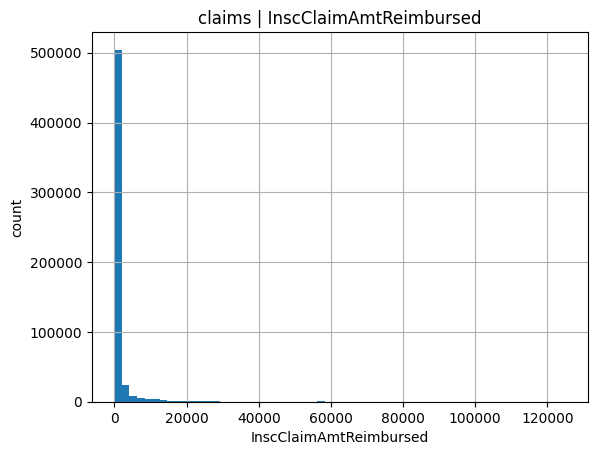

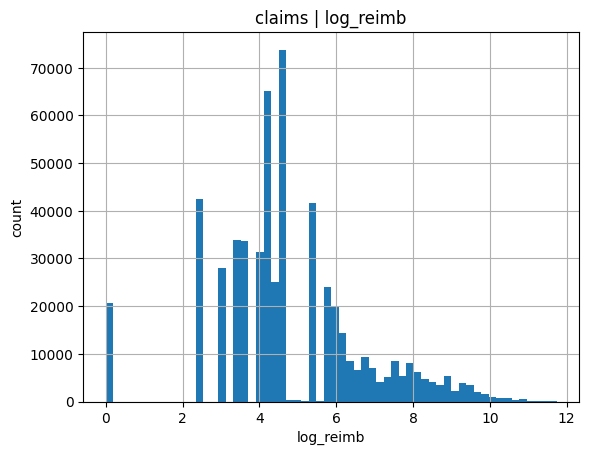

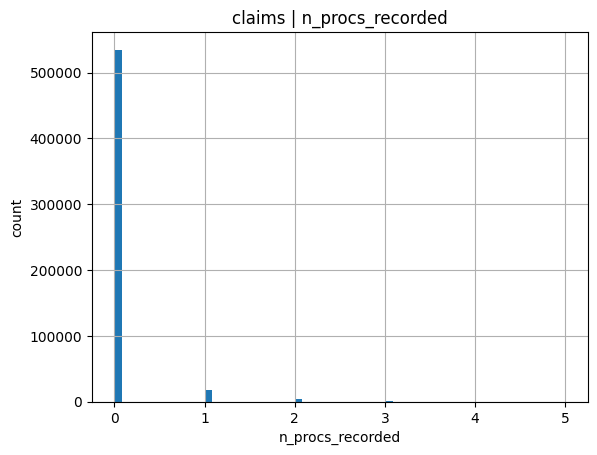

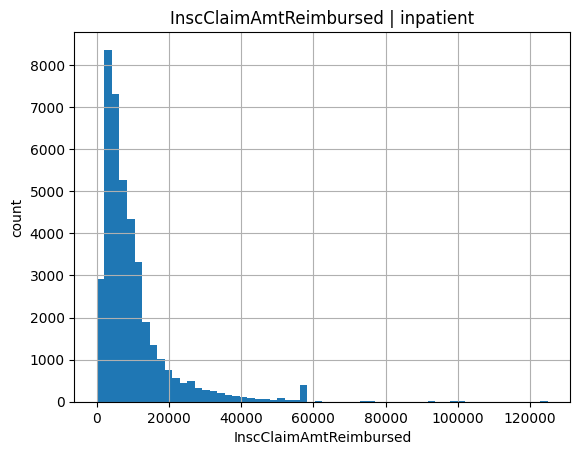

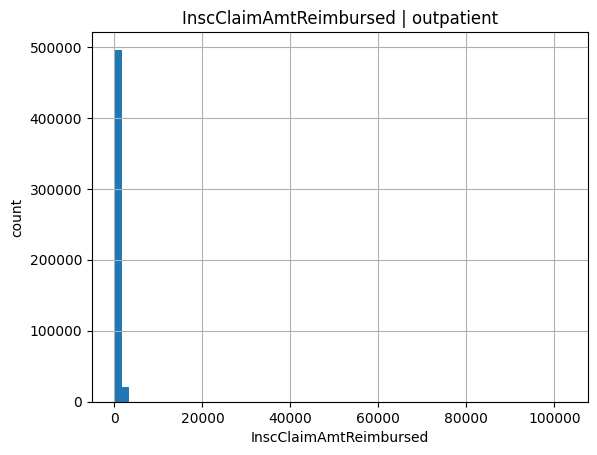

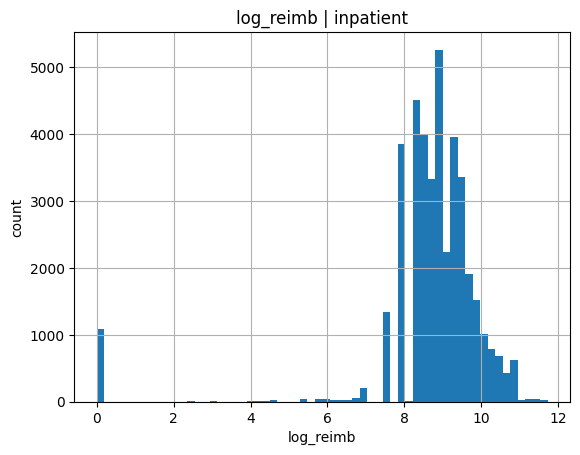

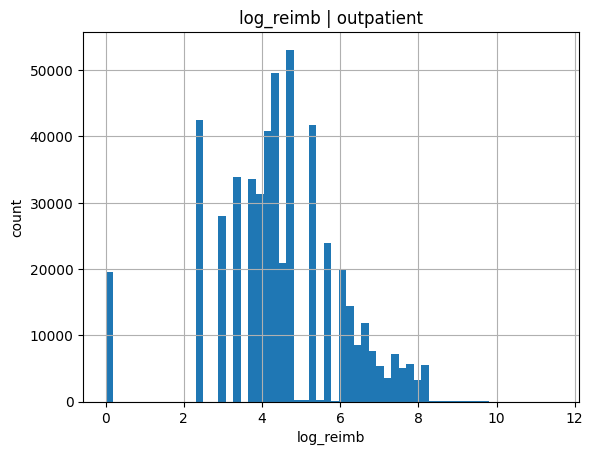

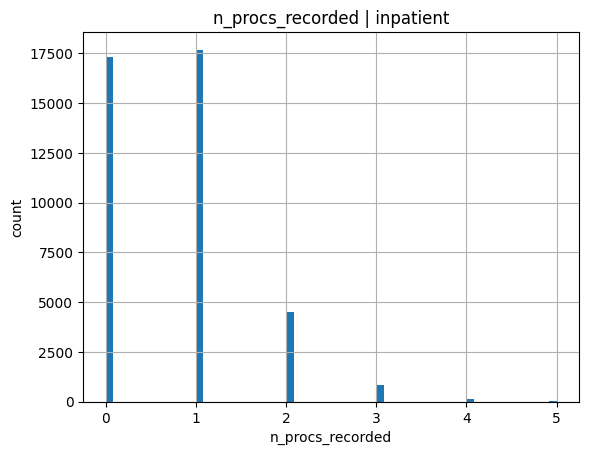

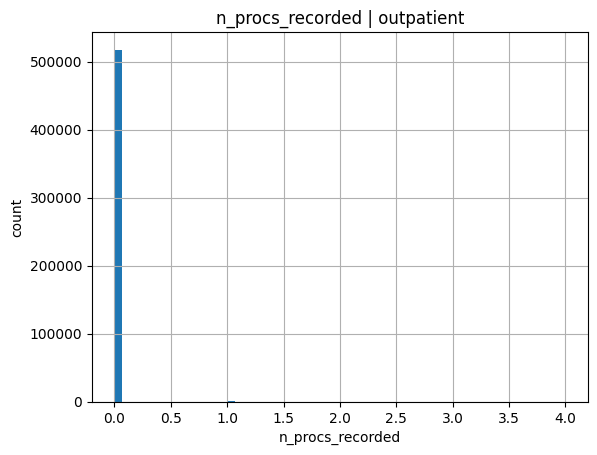


== Top values: Provider ==


,count,share%
Provider,,
PRV51459,8240,1.48
PRV53797,4739,0.85
PRV51574,4444,0.80
PRV53918,3588,0.64
PRV54895,3436,0.62
PRV55215,3393,0.61
PRV52064,2844,0.51
PRV56011,2833,0.51
PRV55004,2399,0.43



== Top values: AttendingPhysician ==


,count,share%
AttendingPhysician,,



== Top values: OperatingPhysician ==


...


== Top values: claim_setting ==


,count,share%
claim_setting,,
outpatient,517737,92.75
inpatient,40474,7.25



== Provider join coverage ==
Coverage of Train providers in provider_features: 100.00%

== Label balance (PotentialFraud) ==


,count
PotentialFraud,
No,4904
Yes,506



=== EDA SUMMARY ===
shapes: {'beneficiaries': (138556, 21), 'claims': (558211, 34), 'provider_features': (5410, 6), 'train': (5410, 2)}
keys_ok: {'beneficiaries.BeneID_unique': True, 'claims.ClaimID_unique': True, 'claims->bene referential': np.float64(1.0)}
top_missing_bene: {'DOD': 0.9897442189439649, 'BeneID': 0.0, 'ChronicCond_Heartfailure': 0.0, 'ChronicCond_rheumatoidarthritis': 0.0, 'ChronicCond_Osteoporasis': 0.0, 'ChronicCond_IschemicHeart': 0.0, 'ChronicCond_Diabetes': 0.0, 'ChronicCond_Depression': 0.0, 'ChronicCond_ObstrPulmonary': 0.0, 'ChronicCond_Cancer': 0.0}
top_missing_claims: {'AttendingPhysician': 1.0, 'ClmProcedureCode_6': 1.0, 'ClmProcedureCode_5': 0.9999838770644075, 'ClmProcedureCode_4': 0.99978861040001, 'ClmProcedureCode_3': 0.998264097267879, 'ClmDiagnosisCode_10': 0.9910248991868666, 'ClmProcedureCode_2': 0.9901650092886023, 'ClmProcedureCode_1': 0.9582415968155411, 'DischargeDt': 0.927493367203441, 'DiagnosisGroupCode': 0.927493367203441}
inpatient_outpati

In [21]:
# ================================
# 📊 EDA on CLEANED/CURATED DATA
# - beneficiaries.parquet
# - claims.parquet
# - (optional) features/provider_features.parquet
# - (optional) data/Train-*.csv  (Provider, PotentialFraud)
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

CURATED_BENE   = "curated/beneficiaries.parquet"
CURATED_CLAIMS = "curated/claims.parquet"
PROV_FEATS     = "features/provider_features.parquet"  # optional
TRAIN_CSV      = "data/Train-1542865627584.csv"        # adjust if needed

# --------- Load ---------
def _read_any(pq_path):
    p = Path(pq_path)
    try:
        return pd.read_parquet(pq_path)
    except Exception:
        csv = p.with_suffix(".csv")
        return pd.read_csv(csv, low_memory=False)

bene = _read_any(CURATED_BENE)
claims = _read_any(CURATED_CLAIMS)

# optional loads
prov = None
if Path(PROV_FEATS).exists() or Path(PROV_FEATS.replace(".parquet",".csv")).exists():
    prov = _read_any(PROV_FEATS)
train = None
if Path(TRAIN_CSV).exists():
    train = pd.read_csv(TRAIN_CSV, low_memory=False)

print("Shapes:")
print("  beneficiaries :", bene.shape)
print("  claims        :", claims.shape)
if prov is not None: print("  provider feats:", prov.shape)
if train is not None: print("  train         :", train.shape)

# --------- 1) Schema + keys + integrity ---------
print("\n== Schema dtypes (first 10 bene & claims) ==")
display(bene.dtypes.head(10).to_frame("dtype"))
display(claims.dtypes.head(10).to_frame("dtype"))

print("\n== Key uniqueness & referential integrity ==")
keys_report = {}
keys_report["beneficiaries.BeneID_unique"] = not bene["BeneID"].duplicated().any()
keys_report["claims.ClaimID_unique"] = ("ClaimID" in claims.columns) and (not claims["ClaimID"].duplicated().any())
keys_report["claims->bene referential"] = claims["BeneID"].astype(str).isin(bene["BeneID"].astype(str)).mean()
display(pd.DataFrame([keys_report]))

# --------- 2) Missingness ---------
def null_table(df, name):
    nt = df.isna().mean().sort_values(ascending=False).to_frame("null_rate")
    nt["dataset"] = name
    return nt

nulls_bene = null_table(bene, "beneficiaries")
nulls_claims = null_table(claims, "claims")
display(nulls_bene.head(20))
display(nulls_claims.head(20))

# --------- 3) Numeric distributions ---------
num_cols = [c for c in claims.columns if pd.api.types.is_numeric_dtype(claims[c])]
focus_nums = [c for c in ["InscClaimAmtReimbursed","log_reimb","n_procs_recorded"] if c in claims.columns]

for c in focus_nums:
    plt.figure()
    claims[c].dropna().hist(bins=60)
    plt.title(f"claims | {c}")
    plt.xlabel(c); plt.ylabel("count")
    plt.show()

# Inpatient vs Outpatient drift on key numerics
if "claim_setting" in claims.columns:
    for c in focus_nums:
        for setting in ["inpatient","outpatient"]:
            if (claims["claim_setting"] == setting).any() and c in claims.columns:
                plt.figure()
                claims.loc[claims["claim_setting"]==setting, c].dropna().hist(bins=60)
                plt.title(f"{c} | {setting}")
                plt.xlabel(c); plt.ylabel("count")
                plt.show()

# --------- 4) Categorical frequencies ---------
def top_k_freq(s: pd.Series, k=15):
    vc = s.value_counts(dropna=True).head(k).to_frame("count")
    vc["share%"] = (vc["count"]/len(s)*100).round(2)
    return vc

cat_candidates = []
for c in ["Provider","AttendingPhysician","OperatingPhysician","OtherPhysician","ClmProcedureCode_1","ClmDiagnosisCode_1","claim_setting"]:
    if c in claims.columns:
        cat_candidates.append(c)

for c in cat_candidates:
    print(f"\n== Top values: {c} ==")
    display(top_k_freq(claims[c], k=20))

# --------- 5) Outliers & caps diagnostics ---------
if "is_amount_capped" in claims.columns:
    rate = claims["is_amount_capped"].mean()
    print(f"\nCapped reimbursements (claims.is_amount_capped==1): {rate:.2%}")

# --------- 6) Provider-level join and label checks (optional) ---------
if (prov is not None) and (train is not None) and ("Provider" in train.columns):
    train["Provider"] = train["Provider"].astype("string")
    prov["Provider"] = prov["Provider"].astype("string")
    joined = train.merge(prov, on="Provider", how="left")
    print("\n== Provider join coverage ==")
    cov = joined["n_claims"].notna().mean()
    print(f"Coverage of Train providers in provider_features: {cov:.2%}")

    # Label balance
    if "PotentialFraud" in train.columns:
        print("\n== Label balance (PotentialFraud) ==")
        display(train["PotentialFraud"].value_counts(dropna=False).to_frame("count"))

    # Check any all-null feature columns post-join
    feat_cols = [c for c in prov.columns if c != "Provider"]
    all_null_cols = [c for c in feat_cols if joined[c].isna().all()]
    if all_null_cols:
        print("\nColumns all-null after join (investigate data coverage or naming):")
        print(all_null_cols)

# --------- 7) Quick “EDA summary” dict to copy into notes ---------
summary = {
    "shapes": {"beneficiaries": bene.shape, "claims": claims.shape,
               **({"provider_features": prov.shape} if prov is not None else {}),
               **({"train": train.shape} if train is not None else {})},
    "keys_ok": keys_report,
    "top_missing_bene": nulls_bene.head(10).to_dict()["null_rate"],
    "top_missing_claims": nulls_claims.head(10).to_dict()["null_rate"],
    "inpatient_outpatient_compared_on": focus_nums,
}
print("\n=== EDA SUMMARY ===")
for k,v in summary.items():
    print(f"{k}: {v}")


### 🚀 How to Use the Cleaned Data

Once you’ve run the data-curation pipeline and generated the cleaned tables, you can move into **exploration, feature engineering, and modeling** confidently.  
Below is a guide for how to use each curated dataset and integrate them into your workflow.

---

#### 1️⃣ Load the cleaned datasets

You’ll have these core files:
- `curated/beneficiaries.parquet`
- `curated/claims.parquet`
- `features/provider_features.parquet` (optional aggregates)
- `data/Train-1542865627584.csv` (labels)

Load them directly in Python:

```python
import pandas as pd

bene = pd.read_parquet("curated/beneficiaries.parquet")
claims = pd.read_parquet("curated/claims.parquet")
provider_feats = pd.read_parquet("features/provider_features.parquet")
train = pd.read_csv("data/Train-1542865627584.csv")
